# 02_all_samples_community.ipynb — The full-cohort view
This notebook takes everything prototyped in notebook 01 and extends it to all ten samples. Rather than Kraken2 reports, the primary classification engine here is local SILVA BLASTn against the SSU NR99 database — more taxonomically precise for rRNA-based community profiling.

Each sample's 16S sequences are BLASTed and parsed into a unified community table. From there the analysis branches into several parallel threads: a presence/absence heatmap shows which taxa are shared across samples; cyanobacteria are separated from non-cyano hits; and three ranked contaminant lists are built for bacteria, fungi, and co-occurring algae — each with dual lollipop plots showing cross-sample prevalence alongside maximum within-sample abundance. All tables are exported to CSV. The notebook closes with a multi-sample cyanobacterial phylogenetic tree, pulling cyano 16S from all samples together and rooting on Gloeobacter kilaueensis to produce the broadest view of cyanobacterial diversity across the dataset.

## Cyanobacteria Metagenomics — All-Samples Community 
**Samples (10 total):** MN-Por-091024-A, TN-Cla-092324-E, WI-Bar-090824-B, NC-Che-092424-E,
KY-Mam-100624-B, KY-Mam-100624-C, GA-Cor-092624-B, FL-Wim-100124-B, MN-Col-091924-B, FL-Hom-052325-G

**Goals:**
1. Profile microbial communities across all 10 samples using 16S rRNA (barrnap + BLAST)
2. Identify overlapping genera/species across samples
3. Flag taxa of interest for antifungal target exploration
4. Build cross-sample comparison visualizations for funder presentations
5. Inform strain isolation priorities

**Why 16S, not Kraken2:** See methodological note below and flags in `01_community_analysis.ipynb`.

**Upstream inputs used:**
- `results/10_tax_profile/{sample}/all_16S.fna` — barrnap on full polished assembly (no Kraken2 pre-filter)
- `results/10_tax_profile/{sample}/barrnap_full.gff` — full rRNA annotation

---
## Methodological Note: 16S vs. K-mer/Contig Classification

### Approach 1 — K-mer classification (Kraken2 on contigs)
Kraken2 classifies assembled contigs by matching k-mers against a reference database.

**How it works:** Each contig is broken into k-mers (short subsequences, typically 31-mers).
Kraken2 looks each k-mer up in a pre-built database and uses lowest common ancestor (LCA)
logic to assign the most specific taxon supported by the majority of k-mers in the contig.

**When it works well:**
- High-coverage assemblies where contigs are long and well-supported
- Organisms that have close relatives in the database
- Enriched samples where target organisms dominate the assembly

**Why it failed here:**
- These are low-coverage, unenriched metagenomes — cyanobacteria represent <1% of reads
- Cyanobacterial lineages from these habitats are underrepresented in
  `kraken2-microbial-fatfree`, causing misclassification or no-hits
- Sparse contigs lack enough k-mers for reliable LCA resolution
- **Confirmed incorrect** for KY-Mam-100624-C: Kraken2 profile did not match 16S phylogenetic placement

**Future applicability:** Once samples are cyano-enriched (selective culture / enrichment sequencing),
coverage across target genomes will be orders of magnitude higher and k-mer classification will be
reliable and fast. Kraken2 is the right tool for that stage.

---

### Approach 2 — 16S rRNA marker gene classification (barrnap + BLAST)
barrnap uses hidden Markov models (HMMs) trained on rRNA gene profiles to identify rRNA genes
directly in assembled contigs. The extracted 16S sequences are then classified via BLAST.

**How it works:** HMM profiles encode the conserved secondary structure and sequence patterns
of 16S rRNA. barrnap scans every contig with nhmmer and extracts any region matching the 16S profile,
regardless of what organism it came from or whether it was in the Kraken2 database.

**Why it works here:**
- Works on full assemblies with no pre-filtering — no Kraken2 dependency
- 16S is the gold-standard marker gene for prokaryotic community profiling
- BLAST against NCBI nt gives direct, interpretable species-level matches
- Phylogenetic placement (tree-based) provides evolutionary context Kraken2 cannot
- Recovers organisms missing from the k-mer database

**Limitations:**
- Only detects organisms whose contigs contain a 16S gene (requires a reasonably complete contig)
- Does not give relative abundance (no read counts — only presence/detection)
- BLAST can be slow for large sequence sets; requires internet or local NCBI db

**Caveat — plastid 16S.** barrnap does not distinguish bacterial 16S from chloroplast 16S,
and SILVA files chloroplast sequences under `Bacteria;Cyanobacteriota;...;Chloroplast`
because plastids descend from cyanobacteria. Any 16S workflow on a photosynthetic
community must therefore separate plastids explicitly — see FLAG 4 in `README.md` for
what happens when it does not. Genomic context (the genes flanking the 16S on the same
contig) is the most reliable discriminator; a phylogeny with chloroplast references
included is the second.

**Bottom line:** For community profiling of these low-coverage metagenomes, 16S + BLAST is
the correct approach, provided plastids are filtered on lineage rather than on label text.
Kraken2 remains in the pipeline for future enriched samples.

---

## 0. Setup

In [ ]:
import os, sys, subprocess, json
from pathlib import Path
import pandas as pd
import numpy as np

# Bootstrap: find project root to load shared utilities
_p = Path.cwd().resolve()
for _parent in [_p] + list(_p.parents):
    if (_parent / 'Snakefile').exists():
        sys.path.insert(0, str(_parent / 'notebooks'))
        break
from utils import (find_project_root, load_config, load_fasta,
                   is_placeholder, parse_title,
                   blast_16S_local, load_blast_results, top_hit_table)

PROJECT = find_project_root()
cfg     = load_config()
print('Project root:', PROJECT)

ALL_SAMPLES = [
    'KY-Mam-100624-B', 'KY-Mam-100624-C',
    'MN-Por-091024-A', 'TN-Cla-092324-E', 'WI-Bar-090824-B',
    'NC-Che-092424-E', 'GA-Cor-092624-B', 'FL-Wim-100124-B',
    'MN-Col-091924-B', 'FL-Hom-052325-G',
]

# Readable labels for plots
SAMPLE_LABELS = {
    'KY-Mam-100624-B': 'KY-Mam-B\n(Green River|MC-NP)',
    'KY-Mam-100624-C': 'KY-Mam-C\n(Echo River|MC-NP)',
    'MN-Por-091024-A': 'MN-Por-A\n(Pigeon River)',
    'TN-Cla-092324-E': 'TN-Cla-E\n(Swan Lake)',
    'WI-Bar-090824-B': 'WI-Bar-B\n(Mirror Lake)',
    'NC-Che-092424-E': 'NC-Che-E\n(Oconaluftee River|SM-NP)',
    'GA-Cor-092624-B': 'GA-Cor-B\n(Lake Blackshear)',
    'FL-Wim-100124-B': 'FL-Wim-B\n(Dude Lake)',
    'MN-Col-091924-B': 'MN-Col-B\n(Lake Superior)',
    'FL-Hom-052325-G': 'FL-Hom-G\n(Eco Pond|E-NP)',
}

# ── Manual sample colors — edit hex values to your preference ──────────────
SAMPLE_COLOR_MAP = {
    'KY-Mam-100624-C': "#0080FE",  # azure blue
    'KY-Mam-100624-B': "#03a2dc",  # deep cerulean
    'MN-Por-091024-A': "#03cc78",  # medium green
    'MN-Col-091924-B': "#04DCBC",  # teal green
    'TN-Cla-092324-E': "#FFDE21",  # yellow
    'GA-Cor-092624-B': "#FF7518",  # pumpkin
    'WI-Bar-090824-B': "#9AF764",  # light grass
    'NC-Che-092424-E': "#cc503e",  # red terracotta
    'FL-Wim-100124-B': "#8A00C4",  # Neon purple
    'FL-Hom-052325-G': "#CD1C18",  # chili red
}

TAX_DIR = PROJECT / 'results' / '10_tax_profile'
FIG_DIR = PROJECT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
import shutil

# ── Tool availability check — run before any other cells ─────────────────────
_required = {
    'blastn':   'BLAST+   (conda: blast)',
    'mafft':    'MAFFT    (conda: mafft)',
    'barrnap':  'barrnap  (conda: barrnap)',
}
_missing = {tool: pkg for tool, pkg in _required.items() if not shutil.which(tool)}
if _missing:
    raise EnvironmentError(
        "Missing tools — activate the correct environment before running:\n" +
        "\n".join(f"  {tool:10s}  {pkg}" for tool, pkg in _missing.items())
    )
# FastTree / IQ-TREE: either is acceptable — checked at tree-building cell (cyano-tree-build)
print("Tool check passed:", list(_required))

## 1. Load 16S Sequences

In [ ]:
# load_fasta imported from utils

# Load all 16S FASTAs
seqs_by_sample = {}
for s in ALL_SAMPLES:
    fna = TAX_DIR / s / 'all_16S.fna'
    if fna.exists():
        seqs = load_fasta(fna)
        seqs_by_sample[s] = seqs
        print(f'{s}: {len(seqs)} 16S sequences')
    else:
        print(f'{s}: MISSING — run extract_16S rule first')
        seqs_by_sample[s] = {}

## 2. BLAST 16S Sequences Against NCBI

Runs online BLAST for each sample. Results cached as JSON — safe to re-run, will skip existing results.

**Note:** NCBI throttles requests. Run once per session; results persist in `results/10_tax_profile/{sample}/blast_16S_all.json`.

In [ ]:
SILVA_DB = cfg['silva_db']

# blast_16S_local imported from utils

for s in ALL_SAMPLES:
    blast_16S_local(s)

## 3. Parse BLAST Results — Per-Sample Community Table

In [ ]:
import re  # still needed by other cells

# is_placeholder, parse_title, load_blast_results, top_hit_table imported from utils

all_hits = pd.concat([top_hit_table(s) for s in ALL_SAMPLES if
                      (TAX_DIR / s / 'blast_16S_silva.json').exists()],
                     ignore_index=True)
print(f'Total 16S sequences: {len(all_hits)}')
print(f'Unique top hits: {all_hits["top_hit"].nunique()}')
all_hits.head(20)

## 4. Cross-Sample Overlap — Shared Taxa

In [432]:
# Taxa present in each sample
taxa_by_sample = {
    s: set(all_hits[all_hits['sample'] == s]['top_hit'].dropna())
    for s in ALL_SAMPLES
}

# Build presence/absence matrix
all_taxa = sorted(set(all_hits['top_hit'].dropna()) - {'No hit'})
pa_matrix = pd.DataFrame(
    {s: [1 if t in taxa_by_sample[s] else 0 for t in all_taxa] for s in ALL_SAMPLES},
    index=all_taxa
)

# Show taxa present in >1 sample
pa_matrix['n_samples'] = pa_matrix.sum(axis=1)
shared = pa_matrix[pa_matrix['n_samples'] > 1].sort_values('n_samples', ascending=False)
print(f'Taxa shared across ≥2 samples: {len(shared)}')
shared

Taxa shared across ≥2 samples: 27


,KY-Mam-100624-B,KY-Mam-100624-C,MN-Por-091024-A,TN-Cla-092324-E,WI-Bar-090824-B,NC-Che-092424-E,GA-Cor-092624-B,FL-Wim-100124-B,MN-Col-091924-B,FL-Hom-052325-G,n_samples
Mesorhizobium sp. NBIMC_P2-C1,1,1,0,1,1,1,0,1,1,0,7
Putative chloroplast,1,1,1,0,1,1,0,1,0,0,6
Bosea sp. AS-1,1,0,0,0,1,1,1,1,0,0,5
Novosphingobium sp. THN1,1,1,0,0,1,1,0,1,0,0,5
Micractinium conductrix,1,1,0,0,0,1,0,1,0,0,4
Fluviicola sp.,0,1,0,0,0,1,1,1,0,0,4
Hydrogenophaga,1,1,0,1,0,0,1,0,0,0,4
Labrys,1,1,0,0,0,1,0,1,0,0,4
Sphingopyxis sp. EG6,1,1,0,0,1,0,0,0,0,0,3
Reyranella,1,1,1,0,0,0,0,0,0,0,3


## 5. Visualization — Presence/Absence Heatmap

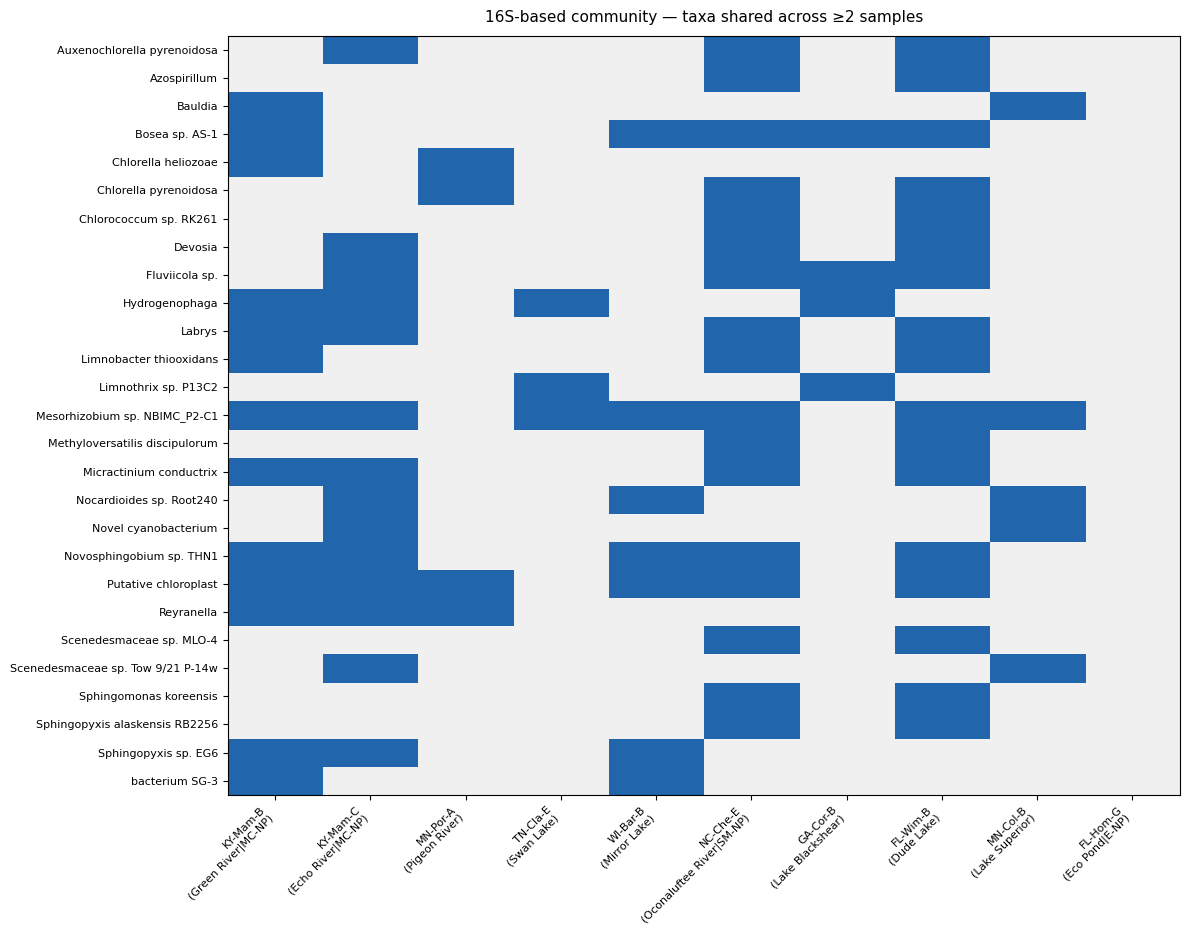

Saved to results/figures/


In [433]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Use shared taxa (≥2 samples) for the heatmap; too many singletons clutters the plot
plot_df = pa_matrix.drop(columns='n_samples')
plot_df = plot_df[plot_df.sum(axis=1) > 1]  # shared only

fig, ax = plt.subplots(figsize=(12, max(6, len(plot_df) * 0.35)))
cmap = mcolors.ListedColormap(['#f0f0f0', '#2166ac'])
im = ax.imshow(plot_df.values, aspect='auto', cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(ALL_SAMPLES)))
ax.set_xticklabels([SAMPLE_LABELS[s] for s in ALL_SAMPLES], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=8)
ax.set_title('16S-based community — taxa shared across ≥2 samples', fontsize=11, pad=10)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_shared_taxa_heatmap.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / '02_shared_taxa_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/figures/')

## 6. Cyanobacteria Summary Across All Samples

In [ ]:
# ── Cyanobacteria vs. plastid classification ─────────────────────────────────
#
# CORRECTED — see FLAG 4 in README.md.
#
# SILVA files chloroplast 16S in TWO places, and both are organelles:
#   Bacteria;Cyanobacteriota;Cyanobacteriia;Chloroplast;...  → SILVA's chloroplast bin
#   Eukaryota;Archaeplastida;Chloroplastida;...              → same organelles, host branch
#
# The first sits under Cyanobacteriota because plastids DESCEND from cyanobacteria by
# primary endosymbiosis — it encodes evolutionary origin, not that the sequence came
# from a free-living cell. A placeholder at the deepest rank ('uncultured',
# 'Incertae Sedis', 'metagenome') means the HOST alga is unidentified in SILVA; it does
# NOT mean the sequence is a novel free-living cyanobacterium.
#
# Earlier versions of this cell counted that case as cyanobacterial. The label
# 'Novel cyanobacterium' was a working marker for "identity unresolved, keep looking" —
# the bug is that this cell consumed it as a positive identification instead of carrying
# it as an open question. Two independent lines of evidence settle it as chloroplast:
#   • results/14_phylo_16S/all_16S.treefile — they form a clade sister to Chlamydomonas
#     reinhardtii chloroplast at 100/100, outside the cyanobacterial radiation
#   • 03a_contig_id_gene_context.ipynb §3 flanking-gene BLASTp — psbC, atpF/atpH and plastid
#     LAGLIDADG intron ORFs at 92–99% identity to green algal chloroplast genomes
#
# Classification now keys off the LINEAGE (is_plastid_lineage / is_cyano_lineage in
# utils.py), never off the parsed label string.

from utils import is_plastid_lineage, is_cyano_lineage, CYANO_KEYWORDS

all_hits['is_chloroplast'] = all_hits['raw_title'].apply(is_plastid_lineage)
all_hits['is_cyano']       = all_hits['raw_title'].apply(is_cyano_lineage)

cyano_summary = []
for s in ALL_SAMPLES:
    df = all_hits[all_hits['sample'] == s]
    cyano_taxa = df[df['is_cyano']]['top_hit'].unique().tolist()
    cyano_summary.append({
        'sample':      s,
        'total_16S':   len(df),
        'cyano_16S':   int(df['is_cyano'].sum()),
        'algae':       int(df['is_chloroplast'].sum()),
        'bacteria':    int((~df['is_cyano'] & ~df['is_chloroplast'] & (df['top_hit'] != 'No hit')).sum()),
        'cyano_taxa':  ', '.join(cyano_taxa) if cyano_taxa else '—',
    })

cyano_df = pd.DataFrame(cyano_summary)
print(cyano_df.to_string(index=False))


In [484]:
non_cyano = all_hits[~all_hits['is_cyano'] & (all_hits['top_hit'] != 'No hit')].copy()

# Genus-level rollup (first word of hit name)
non_cyano['genus'] = non_cyano['top_hit'].str.split().str[0]

# Presence per sample
genus_by_sample = non_cyano.groupby(['genus', 'sample']).size().unstack(fill_value=0)
genus_by_sample['n_samples'] = (genus_by_sample > 0).sum(axis=1)
genus_by_sample = genus_by_sample.sort_values('n_samples', ascending=False)

print('=== Non-cyano genera shared across ≥2 samples ===')
print(genus_by_sample[genus_by_sample['n_samples'] >= 2].to_string())

=== Non-cyano genera shared across ≥2 samples ===
sample             FL-Hom-052325-G  FL-Wim-100124-B  GA-Cor-092624-B  KY-Mam-100624-B  KY-Mam-100624-C  MN-Col-091924-B  MN-Por-091024-A  NC-Che-092424-E  TN-Cla-092324-E  WI-Bar-090824-B  n_samples
genus                                                                                                                                                                                                 
Mesorhizobium                    0                2                0                2                1                1                0                2                1                2          7
Putative                         0                1                0                1                3                0                3                1                0                2          6
Novosphingobium                  0                1                0                1                1                0                0                1 

In [538]:
# Per-sample non-cyano community breakdown
for s in ALL_SAMPLES:
    df = non_cyano[non_cyano['sample'] == s]
    if df.empty:
        print(f'\n{s}: no non-cyano hits')
        continue
    print(f'\n=== {s} ({len(df)} non-cyano 16S) ===')
    print(df[['top_hit', 'pct_id', 'evalue']].to_string(index=False))


=== KY-Mam-100624-B (29 non-cyano 16S) ===
                      top_hit  pct_id  evalue
       Pseudomonas sp. FGI182  99.674     0.0
       Pseudomonas sp. FGI182 100.000     0.0
   Pseudomonas sp. LTGT-11-2Z  99.935     0.0
  Pseudomonas plecoglossicida  99.935     0.0
         Pseudomonas sp. SWI6  99.935     0.0
               bacterium SG-3  99.221     0.0
         Sphingopyxis sp. EG6  98.992     0.0
Mesorhizobium sp. NBIMC_P2-C1 100.000     0.0
Mesorhizobium sp. NBIMC_P2-C1 100.000     0.0
     Novosphingobium sp. THN1  98.246     0.0
                      Bauldia  98.650     0.0
                  Ferrovibrio  98.476     0.0
               Bosea sp. AS-1  99.318     0.0
         Nocardioides alpinus  98.806     0.0
      Limnobacter thiooxidans  99.606     0.0
                   Reyranella  99.527     0.0
      Bradyrhizobium sp. SK17  99.731     0.0
  Prosthecomicrobium hirschii  99.723     0.0
         Variovorax sp. PMC12  99.608     0.0
                       Labrys  99.59

## 8. Ranked Contaminant Lists

**Bacteria:** SILVA BLAST on `all_16S.fna` — non-cyano 16S hits, genus-level rollup.

**Fungi:** Kraken2 contig reports — reliable for fungi (well-represented in its db), two rankings each:
1. **Cross-location:** number of sites detected
2. **Within-sample prevalence:** max % within any single sample

In [539]:
# ── Bacterial contaminant rankings (SILVA, non-cyano) ────────────────────────
bact = all_hits[~all_hits['is_cyano'] & (all_hits['top_hit'] != 'No hit')].copy()
bact['genus'] = bact['top_hit'].str.split().str[0]
# Drop gi| accession IDs that slipped through parse_title
bact = bact[~bact['genus'].str.startswith('gi|')]
# Add:
NON_INFORMATIVE = {'metagenome', 'Uncultured', 'uncultured', 'Unknown', 'unclassified',
                   'Putative', 'putative', 'Unidentified', 'unidentified'}
bact = bact[~bact['genus'].isin(NON_INFORMATIVE)]

# Drop plastid/chloroplast sequences (organellar 16S, not true bacteria)
PLASTID_TERMS = ['chloroplast', 'plastid', 'mitochondri']
plastid_mask = bact['top_hit'].str.lower().apply(
    lambda s: any(t in s for t in PLASTID_TERMS))
if plastid_mask.any():
    print(f'Dropping {plastid_mask.sum()} plastid/mitochondrial hits: '
          f'{bact[plastid_mask]["top_hit"].unique()[:5].tolist()}')
bact = bact[~plastid_mask]

# Ranking 1: number of locations
bact_presence = (bact.groupby(['genus', 'sample']).size().unstack(fill_value=0) > 0).astype(int)
bact_loc = bact_presence.sum(axis=1).rename('n_locations').reset_index()
bact_loc = bact_loc.sort_values('n_locations', ascending=False).reset_index(drop=True)
bact_loc.index += 1
print('=== Bacteria ranked by number of locations ===')
print(bact_loc.head(20).to_string())

# Ranking 2: max within-sample prevalence (% of all 16S seqs in that sample)
sample_totals = all_hits.groupby('sample').size()
bact_counts = bact.groupby(['genus', 'sample']).size()
bact_pct = (bact_counts / sample_totals * 100).round(1).reset_index()
bact_pct.columns = ['genus', 'sample', 'pct_within_sample']
bact_pct_max = bact_pct.sort_values('pct_within_sample', ascending=False).drop_duplicates('genus').reset_index(drop=True)
bact_pct_max.index += 1
print('\n=== Bacteria ranked by max within-sample prevalence ===')
print(bact_pct_max[['genus', 'sample', 'pct_within_sample']].head(20).to_string())


# ── Export to CSV ─────────────────────────────────────────────────────────────
tables_dir = PROJECT / 'results' / 'tables'
tables_dir.mkdir(exist_ok=True)

bact_loc.to_csv(tables_dir / 'bacteria_ranked_by_location.csv')
bact_pct_max[['genus', 'sample', 'pct_within_sample']].to_csv(
    tables_dir / 'bacteria_ranked_by_prevalence.csv', index=False)
print(f'Saved bacterial CSVs to {tables_dir}')

Dropping 1 plastid/mitochondrial hits: ['Mitochondria']
=== Bacteria ranked by number of locations ===
                genus  n_locations
1       Mesorhizobium            7
2               Bosea            5
3        Sphingopyxis            5
4     Novosphingobium            5
5      Scenedesmaceae            4
6           Chlorella            4
7        Nocardioides            4
8              Labrys            4
9      Hydrogenophaga            4
10         Fluviicola            4
11       Micractinium            4
12         Reyranella            3
13            Devosia            3
14        Limnobacter            3
15     Bradyrhizobium            3
16    Auxenochlorella            3
17       Chlorococcum            2
18     Porphyrobacter            2
19  Methyloversatilis            2
20       Sphingomonas            2

=== Bacteria ranked by max within-sample prevalence ===
                genus           sample  pct_within_sample
1       Salinarimonas  FL-Hom-052325-G         

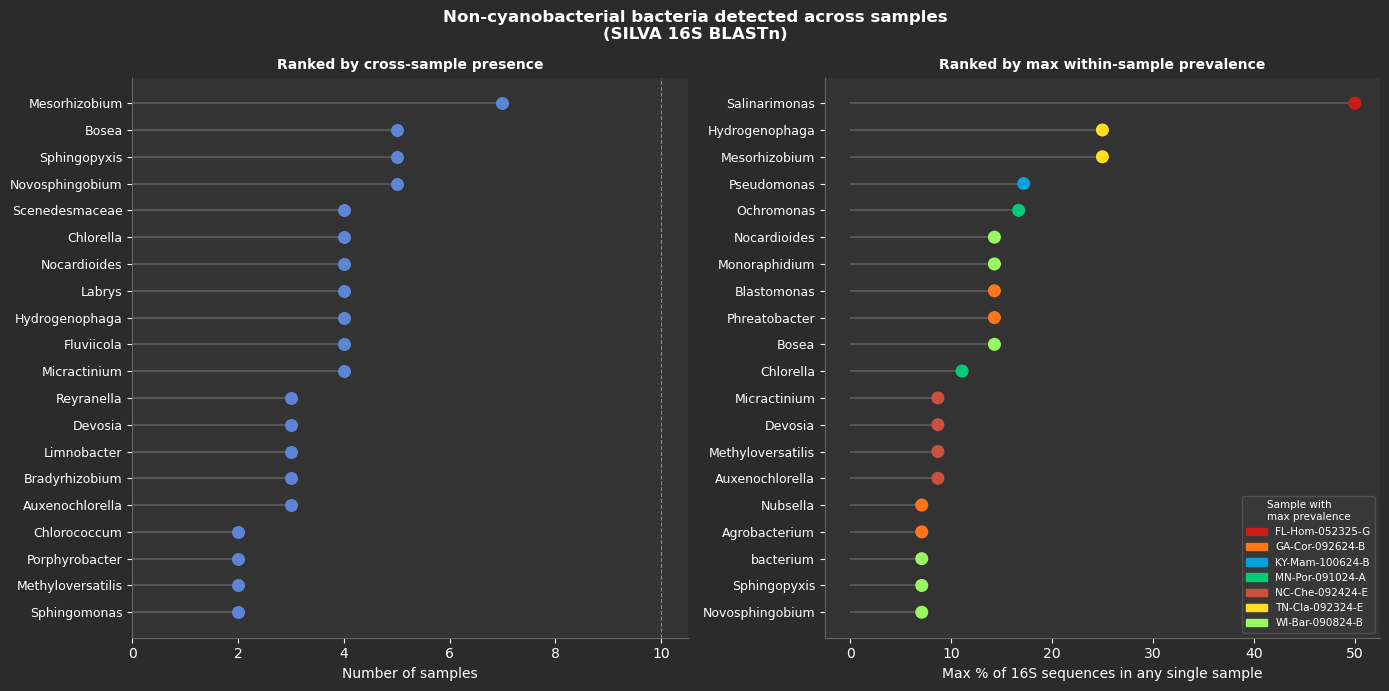

Saved → /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/figures/bacteria_contaminants.pdf


In [540]:
# ── Bacterial contaminant visualization ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TOP_N = 20
BG, AX_BG = '#2b2b2b', '#333333'

with plt.style.context('dark_background'):
    fig, (ax_loc, ax_prev) = plt.subplots(1, 2, figsize=(14, 7), facecolor=BG)
    for _ax in (ax_loc, ax_prev):
        _ax.set_facecolor(AX_BG)
    fig.suptitle('Non-cyanobacterial bacteria detected across samples\n(SILVA 16S BLASTn)',
                 fontsize=12, fontweight='bold')

    # ── Left: ranked by number of locations ──────────────────────────────────
    bl = bact_loc.head(TOP_N).copy()
    bl_genera = bl['genus'].tolist()[::-1]
    bl_n      = bl['n_locations'].tolist()[::-1]

    ax_loc.hlines(range(len(bl_genera)), 0, bl_n, color='#555555', lw=1.5, zorder=1)
    ax_loc.scatter(bl_n, range(len(bl_genera)), color='#5C85D6', s=70, zorder=2)
    ax_loc.set_yticks(range(len(bl_genera)))
    ax_loc.set_yticklabels(bl_genera, fontsize=9)
    ax_loc.set_xlabel('Number of samples', fontsize=10)
    ax_loc.set_title('Ranked by cross-sample presence', fontsize=10, fontweight='bold')
    ax_loc.axvline(len(ALL_SAMPLES), color='#888888', lw=0.8, ls='--')
    ax_loc.set_xlim(0, len(ALL_SAMPLES) + 0.5)
    ax_loc.spines[['top', 'right']].set_visible(False)
    for sp in ax_loc.spines.values(): sp.set_edgecolor('#666666')
    ax_loc.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # ── Right: ranked by max within-sample prevalence ────────────────────────
    bp = bact_pct_max.head(TOP_N).copy()
    bp_genera = bp['genus'].tolist()[::-1]
    bp_pct    = bp['pct_within_sample'].tolist()[::-1]
    bp_sample = bp['sample'].tolist()[::-1]

    colors = [SAMPLE_COLOR_MAP.get(s, '#999999') for s in bp_sample]
    ax_prev.hlines(range(len(bp_genera)), 0, bp_pct, color='#555555', lw=1.5, zorder=1)
    ax_prev.scatter(bp_pct, range(len(bp_genera)), color=colors, s=70, zorder=2)
    ax_prev.set_yticks(range(len(bp_genera)))
    ax_prev.set_yticklabels(bp_genera, fontsize=9)
    ax_prev.set_xlabel('Max % of 16S sequences in any single sample', fontsize=10)
    ax_prev.set_title('Ranked by max within-sample prevalence', fontsize=10, fontweight='bold')
    ax_prev.spines[['top', 'right']].set_visible(False)
    for sp in ax_prev.spines.values(): sp.set_edgecolor('#666666')

    legend_samples = sorted(set(bp_sample))
    handles = [mpatches.Patch(color=SAMPLE_COLOR_MAP.get(s, '#999'), label=s)
               for s in legend_samples]
    ax_prev.legend(handles=handles, fontsize=7.5, loc='lower right',
                   framealpha=0.85, facecolor='#3a3a3a', edgecolor='#555',
                   title='Sample with\nmax prevalence', title_fontsize=7.5)

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'bacteria_contaminants.pdf', bbox_inches='tight', dpi=200, facecolor=BG)
    fig.savefig(FIG_DIR / 'bacteria_contaminants.png', bbox_inches='tight', dpi=200, facecolor=BG)
    plt.show()
    print(f'Saved → {FIG_DIR}/bacteria_contaminants.pdf')


In [487]:
# ── Fungal contaminant rankings (Kraken2 reports) ────────────────────────────
def parse_kraken_fungi(report_path):
    """Extract genus-level fungal hits from a Kraken2 report."""
    rows = []
    in_fungi = False
    fungi_indent = None
    with open(report_path) as f:
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue
            pct, covered, rank, name = parts[0].strip(), parts[1], parts[3], parts[5]
            indent = len(name) - len(name.lstrip())
            name_clean = name.strip()
            if name_clean == 'Fungi':
                in_fungi = True
                fungi_indent = indent
                continue
            if in_fungi:
                if indent <= fungi_indent:
                    in_fungi = False
                    continue
                if rank == 'G':
                    rows.append({'genus': name_clean, 'pct': float(pct), 'n_contigs': int(covered)})
    return rows

fungi_rows = []
for s in ALL_SAMPLES:
    rpt = TAX_DIR / s / 'contigs.kraken.report'
    if not rpt.exists():
        print(f'{s}: no Kraken2 report')
        continue
    for h in parse_kraken_fungi(rpt):
        fungi_rows.append({'sample': s, **h})

fungi_df = pd.DataFrame(fungi_rows)
print(f'Fungal genus detections: {len(fungi_df)} across {fungi_df["sample"].nunique()} samples\n')

# Ranking 1: number of locations
fungi_loc = (fungi_df.groupby(['genus','sample']).size().unstack(fill_value=0) > 0) \
    .astype(int).sum(axis=1).rename('n_locations').reset_index()
fungi_loc = fungi_loc.sort_values('n_locations', ascending=False).reset_index(drop=True)
fungi_loc.index += 1
print('=== Fungi ranked by number of locations ===')
print(fungi_loc.head(20).to_string())

# Ranking 2: max within-sample prevalence (Kraken2 % of all contigs in that sample)
fungi_pct_max = fungi_df.sort_values('pct', ascending=False).drop_duplicates('genus')
fungi_pct_max = fungi_pct_max[['genus','sample','pct','n_contigs']].reset_index(drop=True)
fungi_pct_max.index += 1
print('\n=== Fungi ranked by max within-sample prevalence (% of classified contigs) ===')
print(fungi_pct_max.head(20).to_string())


# ── Export to CSV ─────────────────────────────────────────────────────────────
tables_dir = PROJECT / 'results' / 'tables'
tables_dir.mkdir(exist_ok=True)

fungi_loc.to_csv(tables_dir / 'fungi_ranked_by_location.csv')
fungi_pct_max.to_csv(tables_dir / 'fungi_ranked_by_prevalence.csv', index=False)
print(f'Saved fungal CSVs to {tables_dir}')

Fungal genus detections: 93 across 8 samples

=== Fungi ranked by number of locations ===
               genus  n_locations
1          Thielavia            7
2         Neurospora            7
3           Fusarium            6
4   Thermothelomyces            6
5           Botrytis            6
6        Naumovozyma            5
7           Ustilago            5
8        Aspergillus            4
9       Eremothecium            4
10    Colletotrichum            4
11     Saccharomyces            3
12     Kluyveromyces            3
13          Yarrowia            3
14           Candida            3
15        Cercospora            3
16    Tetrapisispora            3
17      Sugiyamaella            3
18      Zymoseptoria            3
19          Pochonia            3
20      Cryptococcus            3

=== Fungi ranked by max within-sample prevalence (% of classified contigs) ===
                genus           sample   pct  n_contigs
1           Thielavia  MN-Col-091924-B  0.98         37
2   

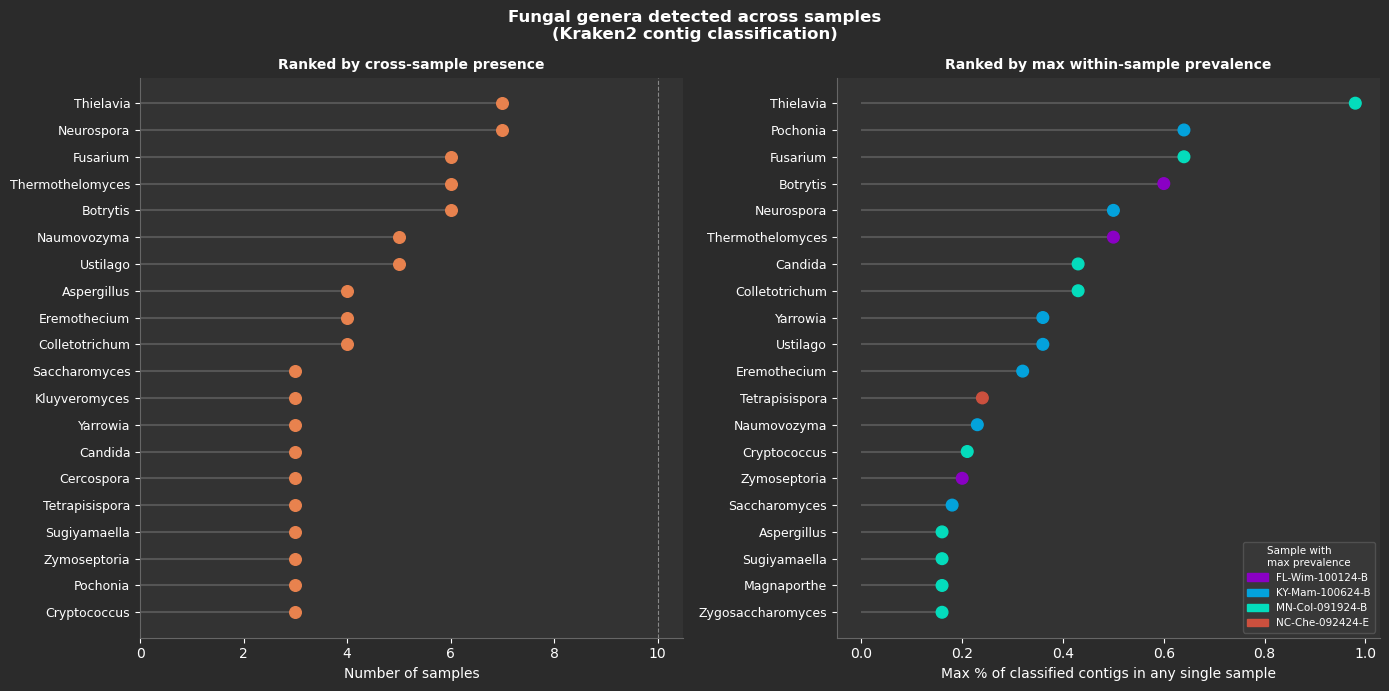

Saved → /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/figures/fungi_contaminants.pdf


In [541]:
# ── Fungal contaminant visualization ──────────────────────────────────────────
import matplotlib.patches as mpatches

TOP_N = 20
BG, AX_BG = '#2b2b2b', '#333333'

with plt.style.context('dark_background'):
    fig, (ax_loc, ax_prev) = plt.subplots(1, 2, figsize=(14, 7), facecolor=BG)
    for _ax in (ax_loc, ax_prev):
        _ax.set_facecolor(AX_BG)
    fig.suptitle('Fungal genera detected across samples\n(Kraken2 contig classification)',
                 fontsize=12, fontweight='bold')

    # ── Left: ranked by number of locations ──────────────────────────────────
    fl = fungi_loc.head(TOP_N).copy()
    fl_genera = fl['genus'].tolist()[::-1]
    fl_n      = fl['n_locations'].tolist()[::-1]

    ax_loc.hlines(range(len(fl_genera)), 0, fl_n, color='#555555', lw=1.5, zorder=1)
    ax_loc.scatter(fl_n, range(len(fl_genera)), color='#E8824E', s=70, zorder=2)
    ax_loc.set_yticks(range(len(fl_genera)))
    ax_loc.set_yticklabels(fl_genera, fontsize=9)
    ax_loc.set_xlabel('Number of samples', fontsize=10)
    ax_loc.set_title('Ranked by cross-sample presence', fontsize=10, fontweight='bold')
    ax_loc.axvline(len(ALL_SAMPLES), color='#888888', lw=0.8, ls='--')
    ax_loc.set_xlim(0, len(ALL_SAMPLES) + 0.5)
    ax_loc.spines[['top', 'right']].set_visible(False)
    for sp in ax_loc.spines.values(): sp.set_edgecolor('#666666')
    ax_loc.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # ── Right: ranked by max within-sample prevalence ────────────────────────
    fp = fungi_pct_max.head(TOP_N).copy()
    fp_genera = fp['genus'].tolist()[::-1]
    fp_pct    = fp['pct'].tolist()[::-1]
    fp_sample = fp['sample'].tolist()[::-1]

    colors = [SAMPLE_COLOR_MAP.get(s, '#999999') for s in fp_sample]
    ax_prev.hlines(range(len(fp_genera)), 0, fp_pct, color='#555555', lw=1.5, zorder=1)
    ax_prev.scatter(fp_pct, range(len(fp_genera)), color=colors, s=70, zorder=2)
    ax_prev.set_yticks(range(len(fp_genera)))
    ax_prev.set_yticklabels(fp_genera, fontsize=9)
    ax_prev.set_xlabel('Max % of classified contigs in any single sample', fontsize=10)
    ax_prev.set_title('Ranked by max within-sample prevalence', fontsize=10, fontweight='bold')
    ax_prev.spines[['top', 'right']].set_visible(False)
    for sp in ax_prev.spines.values(): sp.set_edgecolor('#666666')

    legend_samples = sorted(set(fp_sample))
    handles = [mpatches.Patch(color=SAMPLE_COLOR_MAP.get(s, '#999'), label=s)
               for s in legend_samples]
    ax_prev.legend(handles=handles, fontsize=7.5, loc='lower right',
                   framealpha=0.85, facecolor='#3a3a3a', edgecolor='#555',
                   title='Sample with\nmax prevalence', title_fontsize=7.5)

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'fungi_contaminants.pdf', bbox_inches='tight', dpi=200, facecolor=BG)
    fig.savefig(FIG_DIR / 'fungi_contaminants.png', bbox_inches='tight', dpi=200, facecolor=BG)
    plt.show()
    print(f'Saved → {FIG_DIR}/fungi_contaminants.pdf')


In [542]:
# ── Algal co-occurring taxa (SILVA 18S hits, non-fungal eukaryotes) ───────────
# barrnap detects 18S rRNA in assemblies; SILVA BLAST hits with Eukaryota as
# domain, excluding Opisthokonta (fungi + animals, handled separately).

SKIP_EUK = {'metagenome', 'uncultured', 'unclassified', 'unknown',
            'environmental sample', 'environmental samples',
            'uncultured eukaryote', 'incertae sedis'}

# Supergroups to exclude (fungi/animals already handled; animals unlikely here)
EXCLUDE_SUPERGROUPS = {'Opisthokonta', 'Amoebozoa'}

def euk_group(raw_title):
    """Extract eukaryotic supergroup from SILVA lineage (level 2)."""
    lineage = raw_title.split(' ', 1)[-1] if ' ' in raw_title else raw_title
    nodes = [n.strip() for n in lineage.split(';')]
    if len(nodes) > 1 and nodes[1]:
        return nodes[1]
    return 'Unknown'

def euk_genus(raw_title):
    """Deepest non-placeholder node in SILVA eukaryotic lineage."""
    lineage = raw_title.split(' ', 1)[-1] if ' ' in raw_title else raw_title
    nodes = [n.strip() for n in lineage.split(';')]
    for node in reversed(nodes):
        if node and node.lower() not in SKIP_EUK and not node.lower().startswith('uncultured'):
            return node
    return None

# ── Filter to true eukaryotic hits ───────────────────────────────────────────
euk = all_hits[all_hits['raw_title'].astype(str).str.contains(
    r'^[A-Z0-9]+\.\S+\s+Eukaryota', regex=True)].copy()

euk2 = all_hits[all_hits['raw_title'].astype(str).apply(
    lambda t: 'Eukaryota' in t.split(' ', 1)[-1].split(';')[:2] if ' ' in t else False
)].copy()
euk = pd.concat([euk, euk2]).drop_duplicates()

euk['group'] = euk['raw_title'].apply(euk_group)
euk['genus'] = euk['raw_title'].apply(euk_genus)
euk = euk[euk['genus'].notna()]

# ── Exclude non-algal supergroups ─────────────────────────────────────────────
euk = euk[~euk['group'].isin(EXCLUDE_SUPERGROUPS)]

print(f'Algal 18S detections: {len(euk)} across {euk["sample"].nunique()} samples')
print(f'Supergroups detected: {sorted(euk["group"].unique())}')

# ── Rank by number of locations ───────────────────────────────────────────────
euk_presence = (euk.groupby(['genus', 'sample'])
                   .size().reset_index(name='n')
                   .assign(present=1)
                   .groupby('genus')['present'].sum()
                   .reset_index(name='n_samples')
                   .sort_values('n_samples', ascending=False))

euk_presence['group'] = euk_presence['genus'].map(
    euk.drop_duplicates('genus').set_index('genus')['group'])
euk_presence.index = range(1, len(euk_presence) + 1)

print('\n=== Algae ranked by number of locations ===')
print(euk_presence.head(20).to_string())

# ── Rank by max within-sample prevalence ─────────────────────────────────────
sample_totals = all_hits.groupby('sample').size()
euk_counts    = euk.groupby(['genus', 'sample']).size().reset_index(name='n_hits')
euk_counts['pct_within_sample'] = euk_counts.apply(
    lambda r: r['n_hits'] / sample_totals.get(r['sample'], 1) * 100, axis=1)

euk_pct_max = (euk_counts.sort_values('pct_within_sample', ascending=False)
                          .drop_duplicates('genus')
                          .reset_index(drop=True))
euk_pct_max['group'] = euk_pct_max['genus'].map(
    euk.drop_duplicates('genus').set_index('genus')['group'])
euk_pct_max.index = range(1, len(euk_pct_max) + 1)

print('\n=== Algae ranked by max within-sample prevalence ===')
print(euk_pct_max[['genus', 'group', 'sample', 'pct_within_sample']].head(20).to_string())

# ── Export to CSV ─────────────────────────────────────────────────────────────
tables_dir = PROJECT / 'results' / 'tables'
tables_dir.mkdir(exist_ok=True)

euk_presence.to_csv(tables_dir / 'algae_ranked_by_location.csv')
euk_pct_max[['genus', 'group', 'sample', 'pct_within_sample', 'n_hits']].to_csv(
    tables_dir / 'algae_ranked_by_prevalence.csv', index=False)
print(f'\nSaved algae CSVs to {tables_dir}')


Algal 18S detections: 31 across 7 samples
Supergroups detected: ['Archaeplastida', 'SAR']

=== Algae ranked by number of locations ===
                                genus  n_samples           group
1             Micractinium conductrix          4  Archaeplastida
2         Auxenochlorella pyrenoidosa          3  Archaeplastida
3              Chlorococcum sp. RK261          2  Archaeplastida
4            Scenedesmaceae sp. MLO-4          2  Archaeplastida
5   Scenedesmaceae sp. Tow 9/21 P-14w          2  Archaeplastida
6              Actinastrum hantzschii          1  Archaeplastida
7               Chlorella sorokiniana          1  Archaeplastida
8           Chlorococcum sp. GRK6-DB5          1  Archaeplastida
9                       Chlorophyceae          1  Archaeplastida
10             Desmodesmus pannonicus          1  Archaeplastida
11             Monoraphidium sp. LB59          1  Archaeplastida
12                        Mychonastes          1  Archaeplastida
13            Mychon

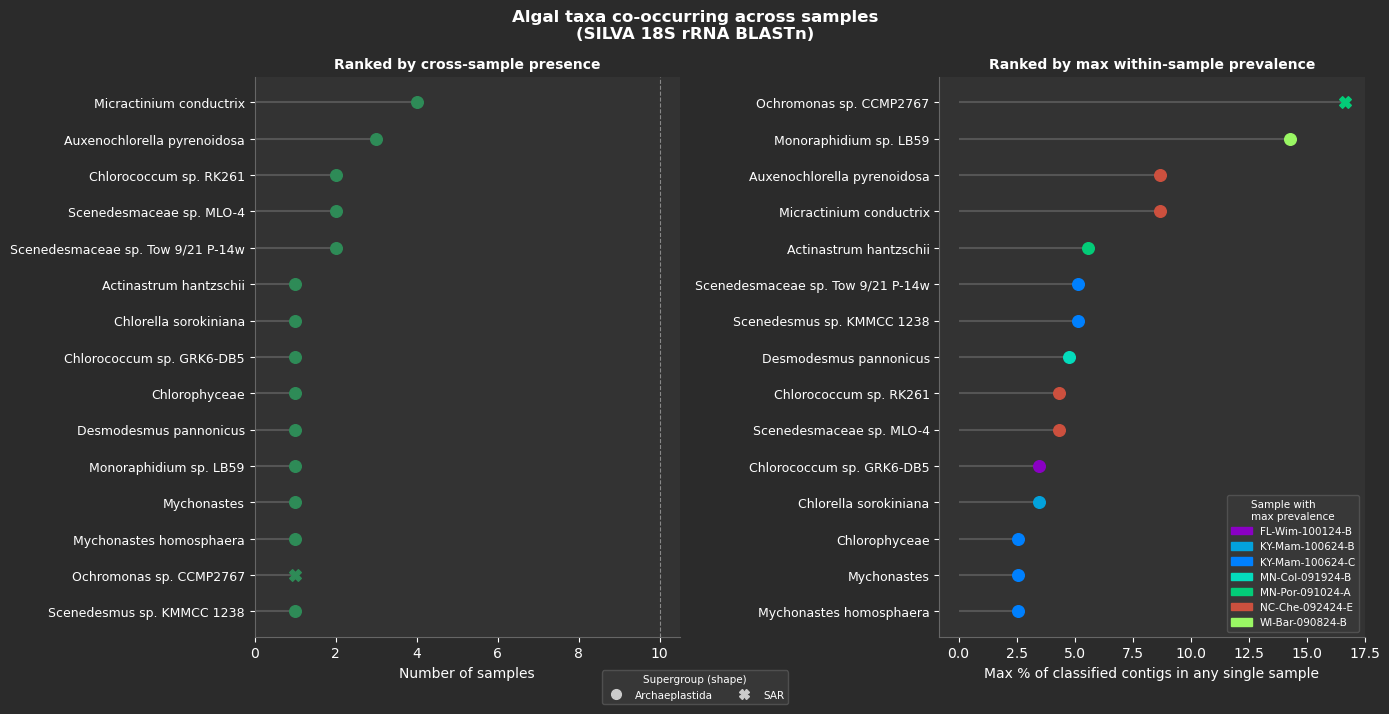

Saved → /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/figures/algae_cooccurring.pdf


In [543]:
# ── Algal co-occurring taxa visualization ─────────────────────────────────────
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

TOP_N = 20
BG, AX_BG = '#2b2b2b', '#333333'

# ── Supergroup → marker shape ─────────────────────────────────────────────────
SUPERGROUP_MARKERS = {
    'Archaeplastida': 'o',
    'Stramenopiles':  '^',
    'Alveolata':      's',
    'Excavata':       'D',
    'Rhizaria':       'P',
    'Unknown':        'X',
}
def sg_marker(g):
    for k in SUPERGROUP_MARKERS:
        if k in str(g):
            return SUPERGROUP_MARKERS[k]
    return 'X'

with plt.style.context('dark_background'):
    fig, (ax_loc, ax_prev) = plt.subplots(1, 2, figsize=(14, 7), facecolor=BG)
    for _ax in (ax_loc, ax_prev):
        _ax.set_facecolor(AX_BG)
    fig.suptitle('Algal taxa co-occurring across samples\n(SILVA 18S rRNA BLASTn)',
                 fontsize=12, fontweight='bold')

    # ── Left: ranked by number of locations ──────────────────────────────────
    el = euk_presence.head(TOP_N).copy()
    el_genera = el['genus'].tolist()[::-1]
    el_n      = el['n_samples'].tolist()[::-1]
    el_grp    = el['group'].tolist()[::-1]

    ax_loc.hlines(range(len(el_genera)), 0, el_n, color='#555555', lw=1.5, zorder=1)
    for yi, (x, grp) in enumerate(zip(el_n, el_grp)):
        ax_loc.scatter(x, yi, color='#2E8B57', marker=sg_marker(grp), s=70, zorder=2)
    ax_loc.set_yticks(range(len(el_genera)))
    ax_loc.set_yticklabels(el_genera, fontsize=9)
    ax_loc.set_xlabel('Number of samples', fontsize=10)
    ax_loc.set_title('Ranked by cross-sample presence', fontsize=10, fontweight='bold')
    ax_loc.axvline(len(ALL_SAMPLES), color='#888888', lw=0.8, ls='--')
    ax_loc.set_xlim(0, len(ALL_SAMPLES) + 0.5)
    ax_loc.spines[['top', 'right']].set_visible(False)
    for sp in ax_loc.spines.values(): sp.set_edgecolor('#666666')
    ax_loc.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


    # ── Right: ranked by max prevalence ──────────────────────────────────────
    ep = euk_pct_max.head(TOP_N).copy()
    ep_genera = ep['genus'].tolist()[::-1]
    ep_pct    = ep['pct_within_sample'].tolist()[::-1]
    ep_sample = ep['sample'].tolist()[::-1]
    ep_grp    = ep['group'].tolist()[::-1]

    ax_prev.hlines(range(len(ep_genera)), 0, ep_pct, color='#555555', lw=1.5, zorder=1)
    for yi, (x, samp, grp) in enumerate(zip(ep_pct, ep_sample, ep_grp)):
        ax_prev.scatter(x, yi,
                        color=SAMPLE_COLOR_MAP.get(samp, '#999999'),
                        marker=sg_marker(grp), s=70, zorder=2)
    ax_prev.set_yticks(range(len(ep_genera)))
    ax_prev.set_yticklabels(ep_genera, fontsize=9)
    ax_prev.set_xlabel('Max % of classified contigs in any single sample', fontsize=10)
    ax_prev.set_title('Ranked by max within-sample prevalence', fontsize=10, fontweight='bold')
    ax_prev.spines[['top', 'right']].set_visible(False)
    for sp in ax_prev.spines.values(): sp.set_edgecolor('#666666')

    legend_samples = sorted(set(ep_sample))
    color_handles = [mpatches.Patch(color=SAMPLE_COLOR_MAP.get(s, '#999'), label=s)
                     for s in legend_samples]
    ax_prev.legend(handles=color_handles, fontsize=7.5, loc='lower right',
                   framealpha=0.85, facecolor='#3a3a3a', edgecolor='#555',
                   title='Sample with\nmax prevalence', title_fontsize=7.5)

    seen_grps_all = list(dict.fromkeys(el_grp + ep_grp))
    shape_handles_shared = [mlines.Line2D([], [], color='#cccccc', marker=sg_marker(g),
                                           linestyle='None', markersize=7, label=g)
                             for g in seen_grps_all]
    fig.legend(handles=shape_handles_shared, fontsize=7.5, loc='lower center',
               ncol=len(seen_grps_all), title='Supergroup (shape)', title_fontsize=7.5,
               framealpha=0.85, facecolor='#3a3a3a', edgecolor='#555',
               bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    fig.savefig(FIG_DIR / 'algae_cooccurring.pdf', bbox_inches='tight', dpi=200, facecolor=BG)
    fig.savefig(FIG_DIR / 'algae_cooccurring.png', bbox_inches='tight', dpi=200, facecolor=BG)
    plt.show()
    print(f'Saved → {FIG_DIR}/algae_cooccurring.pdf')


## 9. Cyanobacteria Phylogenetic Tree — All Samples

Extract cyano 16S from all samples, add curated references, align with MAFFT, tree with FastTree.
Tips labelled `{sample}|{contig}` so placement is traceable to source location.

In [ ]:
# ── Extract cyano 16S, deduplicate by (sample, taxon) ────────────────────────
# For each sample × top_hit group: keep longest sequence, record count + SILVA rank depth

SILVA_RANKS = {1:'domain', 2:'phylum', 3:'class', 4:'order', 5:'family', 6:'genus', 7:'species'}

def silva_rank(raw_title):
    """Estimate taxonomic rank from depth of SILVA lineage string."""
    if ';' not in raw_title:
        return 'unknown'
    lineage = raw_title.split(' ', 1)[-1] if ' ' in raw_title else raw_title
    depth = len([t for t in lineage.split(';') if t.strip()])
    return SILVA_RANKS.get(depth, f'depth-{depth}')

# is_cyano already excludes BOTH SILVA plastid bins (see classification cell
# above), so no extra chloroplast filter is needed — and filtering on the label
# string alone was what let the unnamed-host chloroplast bin through.
cyano_hits = all_hits[all_hits['is_cyano']].copy()
print(f'Total cyano detections before dedup: {len(cyano_hits)}')

combined_fna = TAX_DIR / 'all_samples_cyano_16S.fna'
tip_to_label  = {}   # fasta_id → readable label (shared with viz cell)
written = 0

with open(combined_fna, 'w') as out:
    for s in ALL_SAMPLES:
        fna_path = TAX_DIR / s / 'all_16S.fna'
        if not fna_path.exists():
            continue
        seqs = load_fasta(fna_path)
        sample_cyano = cyano_hits[cyano_hits['sample'] == s]
        short_loc = SAMPLE_LABELS[s].split('\n')[0]

        for taxon, grp in sample_cyano.groupby('top_hit'):
            count = len(grp)
            # Pick longest sequence as representative
            best_row, best_len = None, 0
            for _, row in grp.iterrows():
                seq = seqs.get(row['query'].split()[0], '')
                if len(seq) > best_len:
                    best_len, best_row = len(seq), row
            if best_row is None:
                continue

            rank  = silva_rank(best_row['raw_title'])
            # A genuinely novel cyanobacterium is a real cyanobacterial lineage whose
            # deepest SILVA rank is a placeholder. Refine its rank from percent identity
            # (Yarza et al. 2014, Nature Reviews Microbiology).
            # NOTE: this no longer fires for SILVA's chloroplast bin — those are
            # classified as plastids upstream and never reach cyano_hits.
            _deep = [t.strip() for t in str(best_row['raw_title']).split(';') if t.strip()]
            if _deep and is_placeholder(_deep[-1]):
                pid = best_row['pct_id']
                if pid >= 94.5:
                    rank = 'unknown species'
                elif pid >= 86.5:
                    rank = 'unknown genus'
                elif pid >= 82.0:
                    rank = 'unknown family'
                else:
                    rank = 'unknown order'
            safe_id = best_row['query'].replace('::', '__').replace(':', '_') \
                                       .replace('(', '_').replace(')', '')
            fasta_id = f'{s}|{safe_id}'
            count_str = f' (\u00d7{count})' if count > 1 else ''  # ×
            tip_to_label[fasta_id] = f'{short_loc} \u2014 {taxon} [{rank}]{count_str}'

            out.write(f'>{fasta_id}\n{seqs[best_row["query"].split()[0]]}\n')
            written += 1

print(f'Wrote {written} deduplicated sequences to {combined_fna}')
print(f'(collapsed from {len(cyano_hits)} total cyano detections)')
print('\nTip labels:')
for k, v in tip_to_label.items():
    print(f'  {v}')


In [457]:
# ── Align (MAFFT) + tree (FastTree) ─────────────────────────────────────────
import shutil
from Bio import Phylo

aligned   = TAX_DIR / 'all_samples_cyano_16S_aligned.fna'
tree_file = TAX_DIR / 'all_samples_cyano_16S.nwk'

if not shutil.which('mafft'):
    print('mafft not found — install: conda install -n genomics_arm64 mafft')
else:
    print('Aligning with MAFFT...')
    with open(aligned, 'w') as fout:
        subprocess.run(['mafft', '--auto', '--thread', '4', str(combined_fna)],
                       stdout=fout, check=True)
    print(f'Done → {aligned}')

    fasttree = shutil.which('FastTree') or shutil.which('fasttree')
    if not fasttree:
        print('FastTree not found — install: conda install -n genomics_arm64 fasttree')
    else:
        print('Building tree with FastTree...')
        result = subprocess.run([fasttree, '-nt', '-gtr', str(aligned)],
                                capture_output=True, text=True)
        tree_file.write_text(result.stdout)
        print(f'Done → {tree_file}')


# ── Harmonize novelty ranks within well-supported clades ─────────────────────
# Within any clade with support ≥ 0.95, all members get the most divergent
# (lowest pident) novelty rank — prevents phylogenetic contradictions.

NOVELTY_RANK_ORDER = ['unknown order', 'unknown family', 'unknown genus', 'unknown species']

def get_novelty_rank(label):
    for rank in NOVELTY_RANK_ORDER:
        if f'[{rank}]' in label:
            return rank
    return None

if tree_file.exists():
    _harm_tree = list(Phylo.parse(str(tree_file), 'newick'))[0]
    _harm_tree.root_at_midpoint()

    for clade in _harm_tree.find_clades(order='level'):
        if clade.is_terminal():
            continue
        try:
            if clade.confidence is None or float(clade.confidence) < 0.95:
                continue
        except (TypeError, ValueError):
            continue

        tip_ranks = [(t.name, get_novelty_rank(tip_to_label.get(t.name, '')))
                     for t in clade.get_terminals()
                     if get_novelty_rank(tip_to_label.get(t.name, '')) is not None]

        if len(tip_ranks) < 2:
            continue

        most_novel = min(tip_ranks, key=lambda x: NOVELTY_RANK_ORDER.index(x[1]))[1]

        for tip_name, old_rank in tip_ranks:
            if old_rank != most_novel:
                old_lbl = tip_to_label[tip_name]
                tip_to_label[tip_name] = old_lbl.replace(f'[{old_rank}]', f'[{most_novel}]')
                print(f'  Harmonized: {old_lbl}  →  [{most_novel}]')

    print('Novelty rank harmonization complete')

Aligning with MAFFT...


outputhat23=16
treein = 0
compacttree = 0
stacksize: 8176 kb
generating a scoring matrix for nucleotide (dist=200) ... done
All-to-all alignment.
tbfast-pair (nuc) Version 7.526
alg=L, model=DNA200 (2), 2.00 (6.00), -0.10 (-0.30), noshift, amax=0.0
4 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
generating a scoring matrix for nucleotide (dist=200) ... done
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 9
done.

Progressive alignment ... 
STEP     8 /8 (thread    3) 
done.
tbfast (nuc) Version 7.526
alg=A, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
4 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 4
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
generating a scoring matrix for nucleotide (dist=200) ... done

    0 / 9
Segment   1/  1    1-1570
002-0006-1 (thread    

Done → /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/10_tax_profile/all_samples_cyano_16S_aligned.fna
Building tree with FastTree...
Done → /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/10_tax_profile/all_samples_cyano_16S.nwk
  Harmonized: MN-Col-B — Novel cyanobacterium [unknown species] (×8)  →  [unknown genus]
Novelty rank harmonization complete


002-0014-1 (thread    1) worse         
Converged.
done
dvtditr (nuc) Version 7.526
alg=A, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
4 thread(s)


Strategy:
 L-INS-i (Probably most accurate, very slow)
 Iterative refinement method (<16) with LOCAL pairwise alignment information

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the mafft page.

The default gap scoring scheme has been changed in version 7.110 (2013 Oct).
It tends to insert more gaps into gap-rich regions than previous versions.
To disable this change, add the --leavegappyregion option.



In [ ]:
import matplotlib
# ── Plot tree: dark background, clade brackets, deduplicated tips ────────────
from Bio import Phylo
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.collections as mcoll
from collections import defaultdict

if not tree_file.exists():
    print('Tree not built yet — run build cell first')
else:
    samples_with_cyano = list(cyano_hits['sample'].unique())

    # Fallback: cycle Set2 for any sample not listed above
    cmap_s = plt.cm.Set2
    sample_colors = {
        s: matplotlib.colors.to_rgba(SAMPLE_COLOR_MAP[s]) if s in SAMPLE_COLOR_MAP
        else cmap_s(i / max(len(samples_with_cyano), 1))
        for i, s in enumerate(samples_with_cyano)
    }

    def label_func(clade):
        return tip_to_label.get(clade.name or '', '')

    label_colors = {}
    for fasta_id, label in tip_to_label.items():
        for s in samples_with_cyano:
            if fasta_id.startswith(s + '|'):
                label_colors[label] = sample_colors[s]
                break

    # Build fasta_id → SILVA order-level taxon for bracket annotations
    CYANO_ORDERS = [
        'Nostocales', 'Oscillatoriales', 'Chroococcales', 'Synechococcales',
        'Pleurocapsales', 'Stigonematales', 'Pseudanabaenales',
        'Gloeobacterales', 'Spirulinales', 'Chroococcidiopsidales',
    ]
    def get_order(raw_title):
        for order in CYANO_ORDERS:
            if order in raw_title:
                return order
        # Fallback: 2 levels past Cyanobacteria in the lineage
        if ';' not in raw_title:
            return None
        taxa = [t.strip() for t in raw_title.split(' ', 1)[-1].split(';') if t.strip()]
        try:
            idx = next(i for i, t in enumerate(taxa) if 'Cyanobacteri' in t)
            result = taxa[idx + 2] if len(taxa) > idx + 2 else taxa[-1]
            # 'Chloroplast' here is SILVA's plastid bin, not a cyanobacterial order.
            # Those hits are excluded from cyano_hits upstream, so reaching this branch
            # means something was misclassified — return None rather than relabelling it
            # 'Novel cyanobacteria', which is how the plastids got into the tree before.
            if result == 'Chloroplast':
                return None
            return result
        except StopIteration:
            return None

    fasta_to_order = {}
    for fid in tip_to_label:
        s = fid.split('|')[0]
        safe_id = fid.split('|', 1)[1]
        for _, row in cyano_hits[cyano_hits['sample'] == s].iterrows():
            rs = row['query'].replace('::', '__').replace(':', '_').replace('(', '_').replace(')', '')
            if rs == safe_id:
                order = get_order(row['raw_title'])
                if order:
                    fasta_to_order[fid] = order
                break

    tree = list(Phylo.parse(str(tree_file), 'newick'))[0]
    tree.root_at_midpoint()
    n_tips = len(tree.get_terminals())

    # Compute y positions (mirrors Phylo.draw's internal logic)
    terminals_ordered = tree.get_terminals()
    term_y = {t.name: i + 1 for i, t in enumerate(terminals_ordered)}

    with plt.style.context('dark_background'):
        fig, ax = plt.subplots(figsize=(14, max(8, n_tips * 0.35)))
        fig.patch.set_facecolor('black')
        ax.set_facecolor('black')

        plt.rcParams['font.size'] = 11
        
        import copy

        display_tree = copy.deepcopy(tree)

        Phylo.draw(display_tree, axes=ax, label_func=label_func,
                   label_colors=label_colors, do_show=False)

        # Recolor tree lines (Phylo.draw hardcodes black, draws as LineCollections)
        for coll in ax.collections:
            if isinstance(coll, mcoll.LineCollection):
                coll.set_color('white')

        # Compress tree visually by expanding xlim rightward; add left padding for confidence labels
        _xmax = ax.get_xlim()[1]
        ax.set_xlim(left=-_xmax * 0.2, right=_xmax * 1.5)

        # Shift confidence labels left of branch midpoint
        xlim = ax.get_xlim()
        nudge = (xlim[1] - xlim[0]) * 0.02
        for txt in ax.texts:
            try:
                val = float(txt.get_text())
                if 0.0 <= val <= 1.0:
                    x, y = txt.get_position()
                    txt.set_position((x - nudge*1.2, y - nudge*8))
                    txt.set_ha('right')
            except (ValueError, TypeError):
                pass

        # ── Order-level bracket annotations ──────────────────────────────────
        order_tips = defaultdict(list)
        for fid, order in fasta_to_order.items():
            if fid in term_y:
                order_tips[order].append(fid)

        xmax = ax.get_xlim()[1]
        bx    = xmax * 1.01   # bracket x position
        bpad  = xmax * 0.008  # tick stub length
        lpad  = xmax * 0.012  # label offset from bracket

        def contiguous_runs(ys_sorted, gap=1.5):
            """Split sorted y-values into contiguous groups (gap threshold)."""
            if not ys_sorted: return []
            runs, cur = [], [ys_sorted[0]]
            for y in ys_sorted[1:]:
                if y - cur[-1] <= gap:
                    cur.append(y)
                else:
                    runs.append(cur)
                    cur = [y]
            runs.append(cur)
            return runs

        ROMAN = ['I', 'II', 'III', 'IV', 'V']
        for order, fids in sorted(order_tips.items()):
            ys = sorted([term_y[fid] for fid in fids])
            runs = contiguous_runs(ys)
            runs_sorted = sorted(runs, key=lambda r: r[0])
            multi = len(runs) > 1
            for i, run in enumerate(runs_sorted):
                y_lo = run[0] - 0.4
                y_hi = run[-1] + 0.4
                y_mid = (y_lo + y_hi) / 2
                label = f'{order} ({ROMAN[i]})' if multi else order
                ax.plot([bx, bx], [y_lo, y_hi], color='#aaaaaa', lw=1.2, clip_on=False)
                ax.plot([bx - bpad, bx], [y_lo, y_lo], color='#aaaaaa', lw=1.2, clip_on=False)
                ax.plot([bx - bpad, bx], [y_hi, y_hi], color='#aaaaaa', lw=1.2, clip_on=False)
                ax.text(bx + lpad, y_mid, label, va='center', ha='left',
                        fontsize=12, color='#dddddd', style='italic', clip_on=False)

        # ── Axes styling ──────────────────────────────────────────────────────
        for spine in ax.spines.values():
            spine.set_edgecolor('white')
        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        # Remove y-axis entirely (tip numbers are meaningless)
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_edgecolor('white')
        # Label x-axis meaningfully
        ax.set_xlabel('Evolutionary distance (substitutions/site)', color='white', fontsize=13)
        ax.set_ylabel('Taxa', color='white', fontsize=13)
        ax.tick_params(axis='x', colors='white', labelsize=13)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))
        ax.set_title('Cyanobacteria 16S phylogeny — 7 samples',
                     fontsize=14, pad=10, color='white')

        # Label the right bracket axis
        ax.annotate('Cyanobacterial order', xy=(1.25, 0.5), xycoords='axes fraction',
                    rotation=270, ha='center', va='center', fontsize=13,
                    color='white', style='italic', annotation_clip=False)

        plt.subplots_adjust(right=0.85, left=0.05)
        plt.savefig(FIG_DIR / '09_cyano_tree_all_samples.pdf',
                    bbox_inches='tight', facecolor='black')
        plt.savefig(FIG_DIR / '09_cyano_tree_all_samples.png',
                    dpi=150, bbox_inches='tight', facecolor='black')
        plt.show()
        print('Saved to results/figures/')


## 10. Findings Summary

> **Counts corrected** — see FLAG 4 in `README.md`. Every number below is SILVA-derived
> from the cached BLASTn results (`blast_16S_silva.json`), classified with
> `is_cyano_lineage` / `is_plastid_lineage`. Earlier versions of this table counted
> SILVA's chloroplast bin (`Bacteria;Cyanobacteriota;...;Chloroplast` with an
> unidentified host) as "novel cyanobacteria", and used Kraken2-derived counts for the
> KY-Mam samples. Both are fixed here. Total 16S = `all_16S.fna` sequence count
> (barrnap, full polished assembly).

| Sample | Location | Total 16S | Cyano 16S | Plastid 16S | Cyano lineages (SILVA) | Isolation priority |
|--------|----------|-----------|-----------|-------------|------------------------|--------------------|
| KY-Mam-100624-C | Mammoth Cave, KY (interior) | 39 | **0** | 18 | None by SILVA — see note below | Re-evaluate |
| KY-Mam-100624-B | Mammoth Cave, KY (surface) | 29 | **0** | 3 | None by SILVA | Low |
| MN-Por-091024-A | Portage Lake, MN | 18 | 5 | 7 | *Cyanobium* sp. 2LT07S05, *Cyanodictyon* sp. JJCD, Phormidiaceae | **High** — most diverse cyano sample |
| TN-Cla-092324-E | Clarksville, TN | 4 | 2 | 0 | *Limnothrix* sp. P13C2 | Low — low assembly yield (177 contigs) |
| WI-Bar-090824-B | Barfield Lake, WI | 14 | 0 | 4 | — | Low — no cyanobacteria detected |
| NC-Che-092424-E | Cheraw, NC | 23 | 0 | 7 | — | Low — no cyanobacteria detected |
| GA-Cor-092624-B | Cordele, GA | 14 | 2 | 0 | *Limnothrix* sp. P13C2 | Medium — bloom-forming genus |
| FL-Wim-100124-B | Wimberly Lake, FL | 29 | 0 | 6 | — | Low — no cyanobacteria detected |
| MN-Col-091924-B | Columbia Lake, MN | 21 | 2 | 10 | *Synechococcus elongatus* PCC 7942-like | **High** — target of `04_env7942_assembly.ipynb` |
| FL-Hom-052325-G | Homosassa, FL | 2 | 1 | 0 | Nodosilineaceae (*Nodosilinea*) | **High** — 39.4% cyano by contig; dominant single lineage |

### Cross-sample observations

- **The shared "novel Oscillatoriales genus" resolves as green algal chloroplast.** Contigs
  225, 227, 531, 1504, 427 and 3677 were carried as unresolved candidates — their 16S sits in
  SILVA's chloroplast bin with no named host, which was always ambiguous between a plastid and
  a divergent cyanobacterium. Both purpose-built tests now answer it. In
  `results/14_phylo_16S/all_16S.treefile` all six fall *inside* the Chlorophyta plastid
  radiation, with ***Desmodesmus abundans*** chloroplast nested among them as sister to
  contig_531 at 94.2/98 and the whole group joining *Coelastrella saipanensis* plastid at
  100/100. Their flanking genes are psbC, atpF/atpH and plastid LAGLIDADG intron ORFs at
  92–99% identity to green algal chloroplast genomes (`03a_contig_id_gene_context.ipynb` §3).
  The 93.6–97.5% identity to cyanobacterial references is simply the normal distance from
  plastid 16S — it never indicated novelty.
- **Plastid-dominated samples** now include KY-Mam-100624-C (18/39 plastid) and
  MN-Col-091924-B (10/21) alongside WI-Bar, NC-Che and FL-Wim. Green algae, not
  cyanobacteria, dominate the recoverable 16S signal in most of this cohort.
- **MN-Col-091924-B's *Synechococcus* is genuine.** contig_3535 sits at zero branch length
  from *S. elongatus* PCC 7942 in the tree. `04_env7942_assembly.ipynb` is unaffected by
  this correction, as are the *Limnothrix*, *Cyanobium*, *Nodosilinea* and Phormidiaceae
  assignments.
- **Open item — *Loriellopsis* in the KY-Mam samples.** The earlier *Loriellopsis*
  (Nostocales) call came from a **Cyanobacteria-filtered** NCBI nt BLAST in
  `00_driver_2.0.ipynb` §13, not from SILVA. Restricting the search space to
  Cyanobacteria forces a plastid query onto its nearest free-living cyanobacterial
  relative, which is the same failure mode corrected here. SILVA returns no
  cyanobacterial hit for either KY-Mam sample. Re-run that BLAST unfiltered before
  treating *Loriellopsis* as detected.
- **Isolation priorities**, revised: FL-Hom (abundance), MN-Por (diversity),
  MN-Col (confirmed *Synechococcus*). The KY-Mam cave samples drop off the list until
  the *Loriellopsis* call is re-checked.


In [ ]:
## 11. Self-coverage for all samples — depth per contig
# Runs minimap2 → samtools sort/index → coverm for any sample missing depth.tsv
# Uses: results/02_filter/{sample}.flt.fq.gz  (filtered reads)
#       results/04_polish/{sample}.racon2.fasta (polished assembly)
# Output: results/06_cov/{sample}/depth.tsv

import subprocess, shutil
from pathlib import Path

COVERM    = shutil.which('coverm') or cfg.get('tool_paths', {}).get('coverm')
FILTER_DIR = PROJECT / 'results' / '02_filter'
POLISH_DIR = PROJECT / 'results' / '04_polish'
COV_DIR    = PROJECT / 'results' / '06_cov'

def run_self_coverage(sample, force=False):
    out_dir  = COV_DIR / sample
    depth_f  = out_dir / 'depth.tsv'
    if depth_f.exists() and not force:
        print(f'{sample}: depth.tsv exists, skipping')
        return

    reads    = FILTER_DIR / f'{sample}.flt.fq.gz'
    assembly = POLISH_DIR / f'{sample}.racon2.fasta'
    bam_dir  = out_dir / 'maps'
    bam      = bam_dir / f'{sample}.bam'

    if not reads.exists() or not assembly.exists():
        print(f'{sample}: missing reads or assembly, skipping')
        return

    bam_dir.mkdir(parents=True, exist_ok=True)
    print(f'{sample}: mapping reads → assembly...')

    # minimap2 → sort → index
    mm2 = subprocess.run(
        ['minimap2', '-ax', 'map-ont', '-t', '4', str(assembly), str(reads)],
        capture_output=True)
    sort = subprocess.run(
        ['samtools', 'sort', '-o', str(bam)],
        input=mm2.stdout, capture_output=True)
    subprocess.run(['samtools', 'index', str(bam)], check=True)

    # coverm depth
    print(f'{sample}: running coverm...')
    subprocess.run([
        COVERM, 'contig',
        '-m', 'mean',
        '--bam-files', str(bam),
        '--output-file', str(depth_f),
    ], check=True)
    print(f'{sample}: done → {depth_f}')

for s in ALL_SAMPLES:
    run_self_coverage(s)

KY-Mam-100624-B: depth.tsv exists, skipping
KY-Mam-100624-C: depth.tsv exists, skipping
MN-Por-091024-A: mapping reads → assembly...


In [ ]:
## 12. 16S community coverage — bubble plot across all samples
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
from pathlib import Path
from utils import is_plastid_lineage, is_cyano_lineage

TAX_DIR   = PROJECT / 'results' / '10_tax_profile'
COV_DIR   = PROJECT / 'results' / '06_cov'
FIG_DIR   = PROJECT / 'results' / 'figures'

# ── Load per-sample 16S BLAST top hits + contig depths ───────────────────────
CATEGORY_COLORS = {
    'Cyanobacteria':        '#56B4E9',
    'Putative chloroplast': '#009E73',
    'Other bacteria':       '#999999',
    'No hit':               '#444444',
}

def get_category(raw_title, top_hit):
    # Plastids are tested FIRST. SILVA's chloroplast bin lives at
    # Bacteria;Cyanobacteriota;...;Chloroplast, so the previous 'Cyanobacteriota'
    # substring test counted green algal chloroplasts as cyanobacteria.
    if not raw_title or top_hit == 'No hit':
        return 'No hit'
    if is_plastid_lineage(raw_title):
        return 'Putative chloroplast'
    if is_cyano_lineage(raw_title):
        return 'Cyanobacteria'
    return 'Other bacteria'

rows = []
for s in ALL_SAMPLES:
    # Load BLAST hits
    blast_f = TAX_DIR / s / 'blast_16S_silva.json'
    if not blast_f.exists():
        continue
    blast = json.load(open(blast_f))

    # Load depth for this sample
    depth_f = COV_DIR / s / 'depth.tsv'
    if depth_f.exists():
        dep_df = pd.read_csv(depth_f, sep='\t')
        # Handle two formats:
        #   Snakemake pipeline: contigName, contigLen, totalAvgDepth, {sample}.bam, ...
        #   New runs:           Contig, {sample} Mean
        bam_cols = [c for c in dep_df.columns if c.endswith('.bam')]
        if bam_cols:
            depth_col = bam_cols[0]
            depth_map = dict(zip(dep_df.iloc[:, 0], dep_df[depth_col]))
        else:
            depth_col = dep_df.columns[1]  # '{sample} Mean'
            depth_map = dict(zip(dep_df.iloc[:, 0], dep_df[depth_col]))
    else:
        depth_map = {}

    for qid, hits in blast.items():
        if not hits:
            top_hit, raw_title = 'No hit', ''
        else:
            top = hits[0]
            raw_title = top['title']
            top_hit   = parse_title(raw_title)

        contig = qid.split('::')[1].split(':')[0] if '::' in qid else qid
        depth  = depth_map.get(contig, np.nan)
        cat    = get_category(raw_title, top_hit)

        rows.append({
            'sample':   s,
            'contig':   contig,
            'top_hit':  top_hit,
            'category': cat,
            'depth':    depth,
            'label':    SAMPLE_LABELS.get(s, s).split('\n')[0],
        })

df_all = pd.DataFrame(rows)

# ── Aggregate: per (sample, category) — mean depth + count ───────────────────
agg = (df_all.groupby(['sample', 'category'])
       .agg(count=('contig', 'count'), mean_depth=('depth', 'mean'))
       .reset_index())

# Order samples and categories
sample_order = ALL_SAMPLES
cat_order    = ['Cyanobacteria', 'Putative chloroplast', 'Other bacteria', 'No hit']
agg['sample_idx']   = agg['sample'].map({s: i for i, s in enumerate(sample_order)})
agg['cat_idx']      = agg['category'].map({c: i for i, c in enumerate(cat_order)})
agg = agg.dropna(subset=['sample_idx', 'cat_idx'])

short_labels = [SAMPLE_LABELS.get(s, s).split('\n')[0] for s in sample_order]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#2F2F2F')
ax.set_facecolor('#2F2F2F')

MAX_BUBBLE = 1200
max_count  = agg['count'].max()

for _, row in agg.iterrows():
    size  = (row['count'] / max_count) * MAX_BUBBLE
    color = CATEGORY_COLORS.get(row['category'], '#888888')
    alpha = 0.85 if not np.isnan(row['mean_depth']) else 0.4
    ec    = 'white' if not np.isnan(row['mean_depth']) else '#888888'
    ax.scatter(row['sample_idx'], row['cat_idx'],
               s=size, color=color, alpha=alpha,
               edgecolors=ec, linewidths=0.8, zorder=3)

    # Depth annotation — only on bubbles large enough to read
    if not np.isnan(row['mean_depth']) and row['mean_depth'] > 0 and size > 180:
        ax.text(row['sample_idx'], row['cat_idx'],
                f"{row['mean_depth']:.0f}x",
                ha='center', va='center', fontsize=7,
                color='black', fontweight='bold', zorder=4)

ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=9, color='white')
ax.set_yticks(range(len(cat_order)))
ax.set_yticklabels(cat_order, fontsize=10, color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#555555')
ax.grid(True, color='#444444', lw=0.5, zorder=0)
ax.set_xlim(-0.6, len(sample_order) - 0.4)
ax.set_ylim(-0.6, len(cat_order) - 0.4)

# Bubble size legend — outside plot to avoid overlap, scaled down to fit
LEG_SCALE = 0.25
legend_counts = [2, 10, 25]
legend_handles = [
    ax.scatter([], [], s=(n / max_count) * MAX_BUBBLE * LEG_SCALE,
               color='#aaaaaa', alpha=0.85, edgecolors='white', linewidths=0.8,
               label=f'{n}')
    for n in legend_counts
]
leg = ax.legend(handles=legend_handles, title='Seq. count',
                title_fontsize=8, fontsize=8,
                labelcolor='white', framealpha=0.15,
                bbox_to_anchor=(1.01, 1.0), loc='upper left',
                borderpad=1.0, labelspacing=1.4,
                handletextpad=1.0, scatterpoints=1)
leg.get_title().set_color('white')
leg.get_frame().set_edgecolor('#666666')

ax.set_title('16S rRNA profiles across 10 samples', color='white', fontsize=12, pad=10)
ax.text(0.5, -0.22, 'Bubble size = sequence count  |  Number = mean contig depth (self-coverage)',
        transform=ax.transAxes, ha='center', fontsize=8, color='#aaaaaa')

plt.tight_layout()
plt.savefig(FIG_DIR / '10_16S_coverage_bubble.pdf', bbox_inches='tight', facecolor='#2F2F2F')
plt.savefig(FIG_DIR / '10_16S_coverage_bubble.png', dpi=150, bbox_inches='tight', facecolor='#2F2F2F')
plt.show()
print('Saved → results/figures/10_16S_coverage_bubble.png')


In [479]:
# ── Build single-outgroup tree (G. kilaueensis) ──────────────────────────────
import urllib.request, subprocess, shutil

OUTGROUP_FA_K     = PROJECT / 'db' / 'silva' / 'gloeobacter_kilaueensis_outgroup.fna'
combined_fna_dual = TAX_DIR / 'all_samples_cyano_16S_outgroup.fna'
aln_file_dual     = TAX_DIR / 'all_samples_cyano_16S_outgroup.aln'
tree_file_dual    = TAX_DIR / 'all_samples_cyano_16S_outgroup.nwk'

# Fetch G. kilaueensis 16S if not already present
if not OUTGROUP_FA_K.exists():
    url = ('https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi'
           '?db=nuccore&id=NR_121745.1&rettype=fasta&retmode=text')
    seq = urllib.request.urlopen(url).read().decode()
    seq = seq.replace(
        '>NR_121745.1 Gloeobacter kilaueensis JS1 16S ribosomal RNA, complete sequence',
        '>Outgroup|Gloeobacter_kilaueensis')
    OUTGROUP_FA_K.write_text(seq)
    print('Fetched G. kilaueensis')
else:
    print('G. kilaueensis already cached')

shutil.copy(combined_fna, combined_fna_dual)
with open(combined_fna_dual, 'a') as out:
    out.write(OUTGROUP_FA_K.read_text())

tip_to_label['Outgroup|Gloeobacter_kilaueensis'] = 'Outgroup — G. kilaueensis [species]'
print(f'Combined FASTA written: {combined_fna_dual}')

# MAFFT alignment
subprocess.run(['mafft', '--auto', '--thread', '4', str(combined_fna_dual)],
               stdout=open(aln_file_dual, 'w'), stderr=subprocess.DEVNULL, check=True)
print('Alignment done')

# FastTree
subprocess.run(['FastTree', '-nt', '-gtr', '-quiet', str(aln_file_dual)],
               stdout=open(tree_file_dual, 'w'), stderr=subprocess.DEVNULL, check=True)
print(f'Tree built → {tree_file_dual}')

G. kilaueensis already cached
Combined FASTA written: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/10_tax_profile/all_samples_cyano_16S_outgroup.fna
Alignment done
Tree built → /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/10_tax_profile/all_samples_cyano_16S_outgroup.nwk


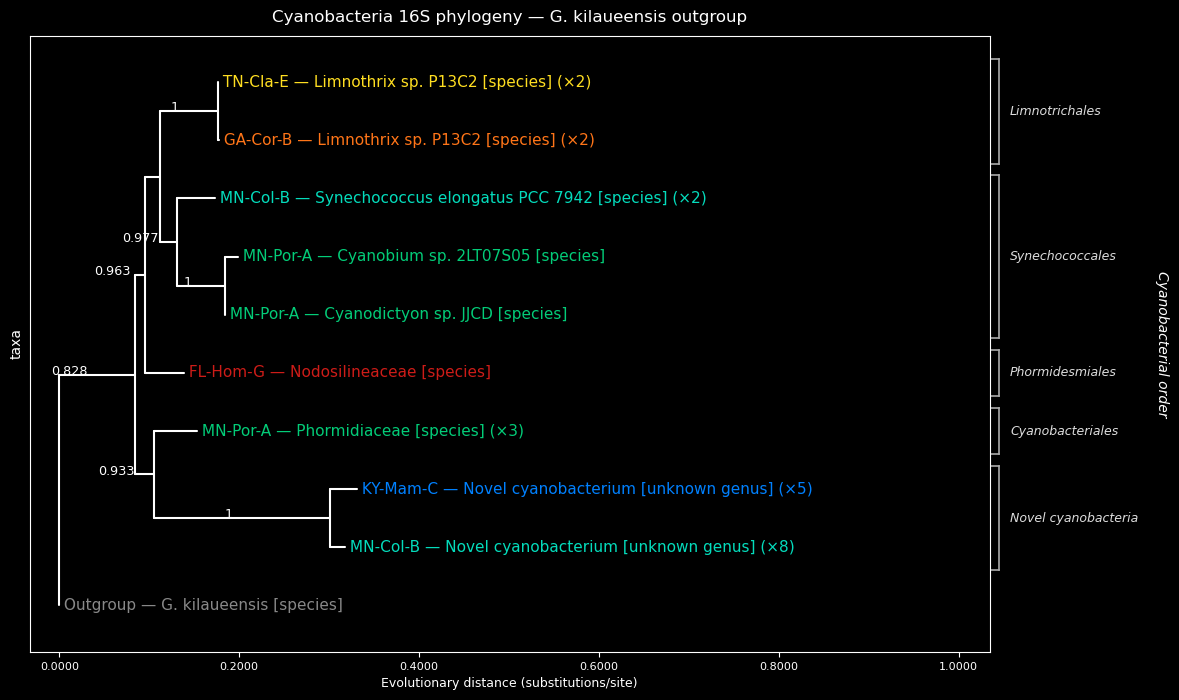

Saved G. kilaueensis outgroup tree


In [ ]:
# ── Viz: single-outgroup tree (G. kilaueensis) ──────────────────────────────
from Bio import Phylo
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.collections as mcoll
from collections import defaultdict
import copy

OUTGROUP_IDS = {'Outgroup|Gloeobacter_kilaueensis'}

tree_d = list(Phylo.parse(str(tree_file_dual), 'newick'))[0]
try:
    tree_d.root_with_outgroup([{'name': oid} for oid in OUTGROUP_IDS])
except Exception:
    tree_d.root_at_midpoint()

terminals_d = tree_d.get_terminals()
term_y_d = {t.name: i + 1 for i, t in enumerate(terminals_d)}
n_tips_d = len(terminals_d)

def label_func_d(clade):
    return tip_to_label.get(clade.name or '', '')

label_colors_d = {}
for fid, lbl in tip_to_label.items():
    if fid in OUTGROUP_IDS:
        label_colors_d[lbl] = '#888888'
    else:
        for s in samples_with_cyano:
            if fid.startswith(s + '|'):
                label_colors_d[lbl] = sample_colors[s]
                break

with plt.style.context('dark_background'):
    fig, ax = plt.subplots(figsize=(12, max(8, n_tips_d * 0.35)))
    fig.patch.set_facecolor('#3a3a3a'); ax.set_facecolor('#3a3a3a')
    plt.rcParams['font.size'] = 11
    Phylo.draw(tree_d, axes=ax, label_func=label_func_d,
               label_colors=label_colors_d, do_show=False)
    for coll in ax.collections:
        if isinstance(coll, mcoll.LineCollection):
            coll.set_color('white')
    _xmax = ax.get_xlim()[1]
    ax.set_xlim(left=-_xmax * 0.08, right=_xmax * 2.5)
    xlim = ax.get_xlim()
    nudge = (xlim[1] - xlim[0]) * 0.01
    for txt in ax.texts:
        try:
            val = float(txt.get_text())
            if 0.0 <= val <= 1.0:
                x, y = txt.get_position()
                txt.set_position((x - nudge, y))
                txt.set_ha('right')
        except (ValueError, TypeError):
            pass
    # Brackets
    def contiguous_runs_d(ys, gap=1.5):
        if not ys: return []
        runs, cur = [], [ys[0]]
        for y in ys[1:]:
            if y - cur[-1] <= gap: cur.append(y)
            else: runs.append(cur); cur = [y]
        runs.append(cur); return runs
    order_tips_d = defaultdict(list)
    for fid, order in fasta_to_order.items():
        if fid in term_y_d and fid not in OUTGROUP_IDS:
            order_tips_d[order].append(fid)
    xmax_d = ax.get_xlim()[1]
    bx_d = xmax_d * 1.01; bpad_d = xmax_d * 0.008; lpad_d = xmax_d * 0.012
    ROMAN = ['I', 'II', 'III', 'IV', 'V']
    for order, fids in sorted(order_tips_d.items()):
        ys = sorted([term_y_d[f] for f in fids])
        runs = sorted(contiguous_runs_d(ys), key=lambda r: r[0])
        multi = len(runs) > 1
        for i, run in enumerate(runs):
            y_lo, y_hi = run[0] - 0.4, run[-1] + 0.4
            label = f'{order} ({ROMAN[i]})' if multi else order
            ax.plot([bx_d, bx_d], [y_lo, y_hi], color='#aaaaaa', lw=1.2, clip_on=False)
            ax.plot([bx_d - bpad_d, bx_d], [y_lo, y_lo], color='#aaaaaa', lw=1.2, clip_on=False)
            ax.plot([bx_d - bpad_d, bx_d], [y_hi, y_hi], color='#aaaaaa', lw=1.2, clip_on=False)
            ax.text(bx_d + lpad_d, (y_lo + y_hi) / 2, label, va='center', ha='left',
                    fontsize=9, color='#dddddd', style='italic', clip_on=False)
    for spine in ax.spines.values(): spine.set_edgecolor('white')
    ax.tick_params(colors='white')
    ax.yaxis.set_tick_params(left=False, labelleft=False)
    ax.spines['left'].set_visible(True); ax.spines['left'].set_edgecolor('white')
    ax.set_xlabel('Evolutionary distance (substitutions/site)', color='white', fontsize=9)
    ax.tick_params(axis='x', colors='white', labelsize=8)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))
    ax.set_title('Cyanobacteria 16S phylogeny — G. kilaueensis outgroup',
                 fontsize=12, pad=10, color='white')
    ax.annotate('Cyanobacterial order', xy=(1.18, 0.5), xycoords='axes fraction',
                rotation=270, ha='center', va='center', fontsize=10,
                color='white', style='italic', annotation_clip=False)
    plt.subplots_adjust(right=0.85, left=0.05)
    plt.savefig(FIG_DIR / '09_cyano_tree_dual_outgroup.png', dpi=150, bbox_inches='tight', facecolor='black')
    plt.show()
    print('Saved G. kilaueensis outgroup tree')

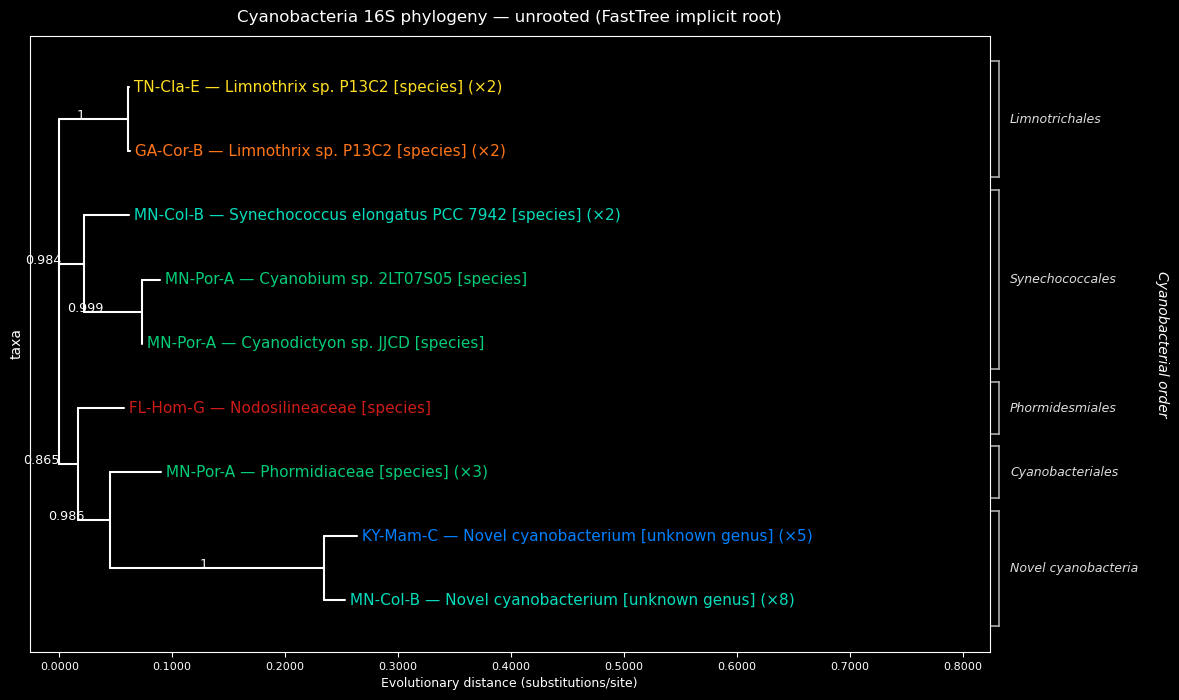

Saved unrooted tree


In [481]:
# ── Viz: unrooted tree (no root assigned — FastTree implicit root) ────────────
from Bio import Phylo
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
from collections import defaultdict

tree_u = list(Phylo.parse(str(tree_file), 'newick'))[0]
# No rooting call — tree is drawn as-is from FastTree output

terminals_u = tree_u.get_terminals()
term_y_u = {t.name: i + 1 for i, t in enumerate(terminals_u)}
n_tips_u = len(terminals_u)
OUTGROUP_ID_U = 'Outgroup|Gloeobacter_violaceus'

def label_func_u(clade):
    return tip_to_label.get(clade.name or '', '')

label_colors_u = {}
for fid, lbl in tip_to_label.items():
    if fid == OUTGROUP_ID_U:
        label_colors_u[lbl] = '#888888'
    else:
        for s in samples_with_cyano:
            if fid.startswith(s + '|'):
                label_colors_u[lbl] = sample_colors[s]
                break

with plt.style.context('dark_background'):
    fig, ax = plt.subplots(figsize=(12, max(8, n_tips_u * 0.35)))
    fig.patch.set_facecolor('black'); ax.set_facecolor('black')
    plt.rcParams['font.size'] = 11
    Phylo.draw(tree_u, axes=ax, label_func=label_func_u,
               label_colors=label_colors_u, do_show=False)
    for coll in ax.collections:
        if isinstance(coll, mcoll.LineCollection):
            coll.set_color('white')
    _xmax = ax.get_xlim()[1]
    ax.set_xlim(left=-_xmax * 0.08, right=_xmax * 2.5)
    xlim = ax.get_xlim()
    nudge = (xlim[1] - xlim[0]) * 0.01
    for txt in ax.texts:
        try:
            val = float(txt.get_text())
            if 0.0 <= val <= 1.0:
                x, y = txt.get_position()
                txt.set_position((x - nudge, y))
                txt.set_ha('right')
        except (ValueError, TypeError):
            pass
    def contiguous_runs_u(ys, gap=1.5):
        if not ys: return []
        runs, cur = [], [ys[0]]
        for y in ys[1:]:
            if y - cur[-1] <= gap: cur.append(y)
            else: runs.append(cur); cur = [y]
        runs.append(cur); return runs
    order_tips_u = defaultdict(list)
    for fid, order in fasta_to_order.items():
        if fid in term_y_u and fid != OUTGROUP_ID_U:
            order_tips_u[order].append(fid)
    xmax_u = ax.get_xlim()[1]
    bx_u = xmax_u * 1.01; bpad_u = xmax_u * 0.008; lpad_u = xmax_u * 0.012
    ROMAN = ['I', 'II', 'III', 'IV', 'V']
    for order, fids in sorted(order_tips_u.items()):
        ys = sorted([term_y_u[f] for f in fids])
        runs = sorted(contiguous_runs_u(ys), key=lambda r: r[0])
        multi = len(runs) > 1
        for i, run in enumerate(runs):
            y_lo, y_hi = run[0] - 0.4, run[-1] + 0.4
            label = f'{order} ({ROMAN[i]})' if multi else order
            ax.plot([bx_u, bx_u], [y_lo, y_hi], color='#aaaaaa', lw=1.2, clip_on=False)
            ax.plot([bx_u - bpad_u, bx_u], [y_lo, y_lo], color='#aaaaaa', lw=1.2, clip_on=False)
            ax.plot([bx_u - bpad_u, bx_u], [y_hi, y_hi], color='#aaaaaa', lw=1.2, clip_on=False)
            ax.text(bx_u + lpad_u, (y_lo + y_hi) / 2, label, va='center', ha='left',
                    fontsize=9, color='#dddddd', style='italic', clip_on=False)
    for spine in ax.spines.values(): spine.set_edgecolor('white')
    ax.tick_params(colors='white')
    ax.yaxis.set_tick_params(left=False, labelleft=False)
    ax.spines['left'].set_visible(True); ax.spines['left'].set_edgecolor('white')
    ax.set_xlabel('Evolutionary distance (substitutions/site)', color='white', fontsize=9)
    ax.tick_params(axis='x', colors='white', labelsize=8)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))
    ax.set_title('Cyanobacteria 16S phylogeny — unrooted (FastTree implicit root)',
                 fontsize=12, pad=10, color='white')
    ax.annotate('Cyanobacterial order', xy=(1.18, 0.5), xycoords='axes fraction',
                rotation=270, ha='center', va='center', fontsize=10,
                color='white', style='italic', annotation_clip=False)
    plt.subplots_adjust(right=0.85, left=0.05)
    plt.savefig(FIG_DIR / '09_cyano_tree_unrooted.png', dpi=150, bbox_inches='tight', facecolor='black')
    plt.show()
    print('Saved unrooted tree')

Saved PNG: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/results/figures/09_cyano_tree_unrooted_toytree.png
Done — toytree unrooted layout


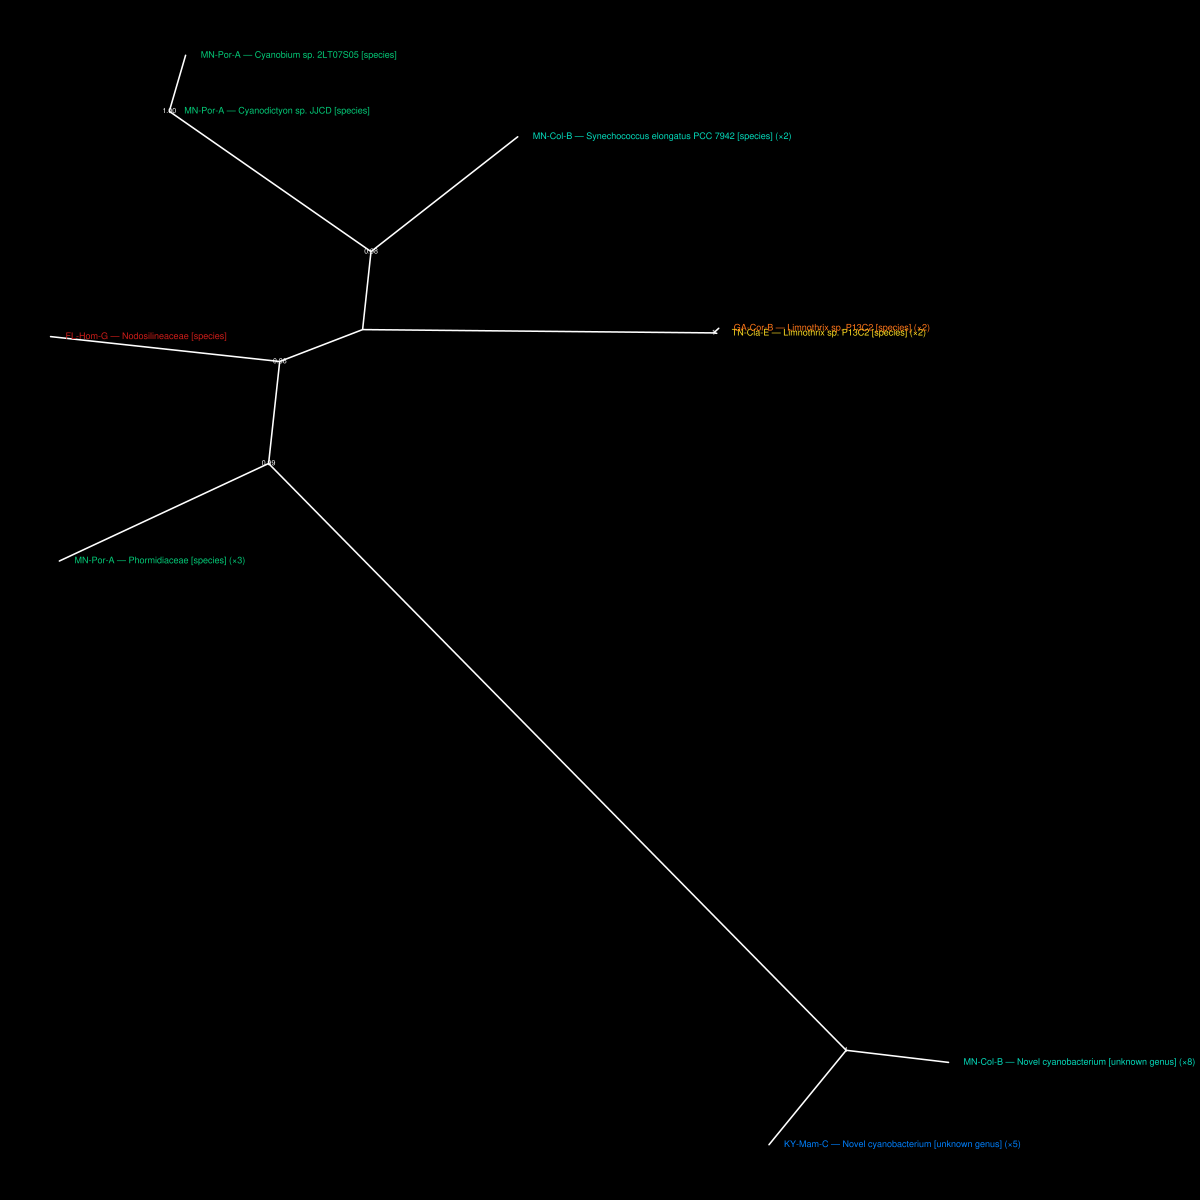

In [482]:
# ── Toytree: truly unrooted radial tree ──────────────────────────────────────
import toytree
import toyplot
import toyplot.svg
import toyplot.png

# Load tree — do NOT root it (use raw FastTree output topology)
tre = toytree.tree(str(tree_file))

# Build tip label + color mappings keyed by toytree tip order
tip_names = tre.get_tip_labels()

tip_labels_display = [tip_to_label.get(n, n) for n in tip_names]

def _tip_color(fasta_id):
    for s in samples_with_cyano:
        if fasta_id.startswith(s + '|'):
            return '#%02x%02x%02x' % tuple(int(c * 255) for c in sample_colors[s][:3])
    return '#888888'

tip_colors = [_tip_color(n) for n in tip_names]

# Node support values (skip root and tips)
node_labels = []
for node in sorted(tre.get_nodes(), key=lambda n: n.idx):
    if node.is_leaf() or node.is_root():
        node_labels.append('')
    else:
        try:
            val = float(node.support)
            node_labels.append(f'{val:.2f}' if val < 1.0 else '1')
        except (TypeError, ValueError):
            node_labels.append('')

canvas, axes, mark = tre.draw(
    layout='unrooted',
    width=1200,
    height=1200,
    tip_labels=tip_labels_display,
    tip_labels_colors=tip_colors,
    tip_labels_angles=0,
    tip_labels_align=True,
    tip_labels_style={'font-size': '9px'},
    node_labels=node_labels,
    node_labels_style={'font-size': '7px', 'fill': 'white'},
    node_sizes=0,
    edge_style={'stroke': 'white', 'stroke-width': 1.5},
    node_style={'fill': 'none', 'stroke': 'none'},
    padding=180,
)

# Dark background
axes.padding = 180
canvas.style['background-color'] = 'black'

# Save
out_svg = FIG_DIR / '09_cyano_tree_unrooted_toytree.svg'
out_png = FIG_DIR / '09_cyano_tree_unrooted_toytree.png'
toyplot.svg.render(canvas, str(out_svg))
try:
    toyplot.png.render(canvas, str(out_png), scale=2)
    print(f'Saved PNG: {out_png}')
except Exception as e:
    print(f'PNG save failed ({e}); SVG saved: {out_svg}')

print('Done — toytree unrooted layout')
canvas

Confidence values: [0.865, 0.984, 0.986, 0.999, 1.0, 1.0]
vmin: 0.665


/var/folders/cr/9y9g3zs15tn8hr54m5nn72200000gn/T/ipykernel_17069/1121198266.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


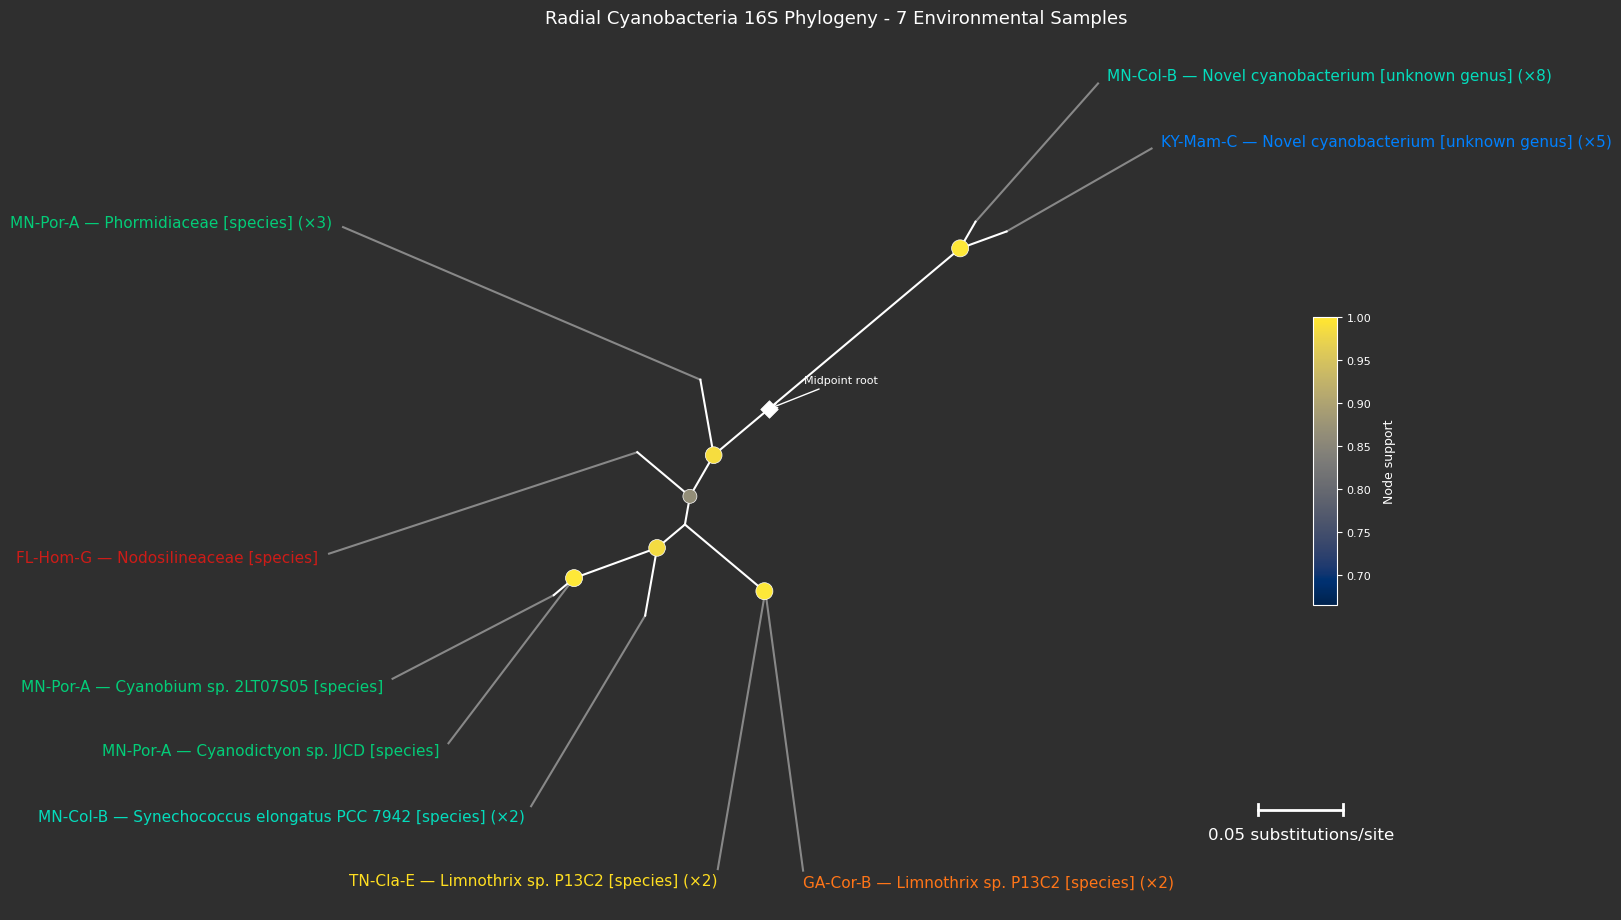

Saved → results/figures/09_cyano_tree_radial_mpl.png


In [483]:
# ── Matplotlib unrooted tree with label spreading ────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from Bio import Phylo
import copy

# ── 1. Compute unrooted layout coordinates ────────────────────────────────────
def compute_unrooted_layout(tree):
    t = copy.deepcopy(tree)
    t.root_at_midpoint()

    def count_tips(cl):
        if cl.is_terminal():
            cl._ntips = 1
            return 1
        n = sum(count_tips(c) for c in cl.clades)
        cl._ntips = n
        return n
    count_tips(t.root)

    # Minimum display length for internal branches (so short-BL nodes stay visible)
    all_bls = [cl.branch_length for cl in t.find_clades()
               if cl.branch_length is not None and cl.branch_length > 0]
    max_bl = max(all_bls) if all_bls else 1.0
    MIN_BL = max_bl * 0.06  # 6% of longest branch → always visible

    coords = {id(t.root): np.array([0.0, 0.0])}

    def recurse(clade, x0, y0, a_start, a_end):
        a_mid = (a_start + a_end) / 2.0
        raw_bl = clade.branch_length if clade.branch_length else 1e-6
        # Apply minimum only to internal nodes; leave terminal lengths true
        bl = max(raw_bl, MIN_BL) if not clade.is_terminal() else raw_bl
        x = x0 + bl * np.cos(a_mid)
        y = y0 + bl * np.sin(a_mid)
        coords[id(clade)] = np.array([x, y])
        if not clade.is_terminal():
            cur = a_start
            for child in clade.clades:
                span = (a_end - a_start) * child._ntips / clade._ntips
                recurse(child, x, y, cur, cur + span)
                cur += span

    cur = 0.0
    for child in t.root.clades:
        span = 2 * np.pi * child._ntips / t.root._ntips
        recurse(child, 0, 0, cur, cur + span)
        cur += span

    return t, coords

_tree_fresh = list(Phylo.parse(str(tree_file), 'newick'))[0]
t_plot, coords = compute_unrooted_layout(_tree_fresh)

# ── 2. Natural radial label placement with angular separation ────────────────
terminals = t_plot.get_terminals()
nat_angles = {}
for tip in terminals:
    x, y = coords[id(tip)]
    nat_angles[tip.name] = np.arctan2(y, x)

max_r   = max(np.linalg.norm(coords[id(tip)]) for tip in terminals)
label_r = max_r * 1.6

# Spread labels angularly to enforce minimum separation — keeps connectors radial
MIN_ANG = 0.18  # radians (~10°), increase if still overlapping

sorted_tips = sorted(terminals, key=lambda t: nat_angles[t.name])
spread_angles = [nat_angles[t.name] for t in sorted_tips]

for _ in range(500):
    moved = False
    for i in range(len(spread_angles) - 1):
        diff = spread_angles[i + 1] - spread_angles[i]
        if diff < MIN_ANG:
            push = (MIN_ANG - diff) / 2
            spread_angles[i]     -= push
            spread_angles[i + 1] += push
            moved = True
    if not moved:
        break

label_pos = {}
for tip, ang in zip(sorted_tips, spread_angles):
    lx = label_r * np.cos(ang)
    ly = label_r * np.sin(ang)
    ha = 'left' if lx >= 0 else 'right'
    label_pos[tip.name] = [lx, ly, ha]

_debug_confs = sorted([
    float(cl.confidence) 
    for cl in _tree_fresh.find_clades() 
    if not cl.is_terminal() and cl.confidence is not None
])
print('Confidence values:', _debug_confs)
print('vmin:', _vmin)

# ── 3. Draw ────────────────────────────────────────────────────────────────────

with plt.style.context('dark_background'):
    fig, ax = plt.subplots(figsize=(16, 16))
    fig.patch.set_facecolor("#2F2F2F")
    ax.set_facecolor("#2F2F2F")
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Edges: all white ─────────────────────────────────────────────────────────
    def draw_edges(clade):
        x0, y0 = coords[id(clade)]
        for child in clade.clades:
            x1, y1 = coords[id(child)]
            ax.plot([x0, x1], [y0, y1], color='white', lw=1.5, zorder=2)
            draw_edges(child)
    draw_edges(t_plot.root)

    # ── Internal node dots colored + sized by support ─────────────────────────
    from matplotlib.colors import Normalize
    conf_cmap = plt.cm.cividis
    _conf_vals = [float(cl.confidence) for cl in t_plot.find_clades()
                  if not cl.is_terminal() and cl.confidence is not None]
    _vmin = min(_conf_vals)-0.2 if _conf_vals else 0.0
    conf_norm = Normalize(vmin=_vmin, vmax=1.0)

    dot_xs, dot_ys, dot_colors, dot_sizes = [], [], [], []
    for cl in t_plot.find_clades():
        if cl.is_terminal() or cl is t_plot.root:
            continue
        if cl.confidence is None:
            continue
        try:
            val = float(cl.confidence)
        except (TypeError, ValueError):
            continue
        x, y = coords[id(cl)]
        dot_xs.append(x)
        dot_ys.append(y)
        dot_colors.append(conf_cmap(conf_norm(val)))
        dot_sizes.append(30 + 120 * conf_norm(val))  # larger = higher support

    sc = ax.scatter(dot_xs, dot_ys, c=dot_colors, s=dot_sizes,
                    zorder=3, edgecolors='white', linewidths=0.5)

    # Root node annotation
    ax.scatter([0], [0], s=80, marker='D', color='white', zorder=5,
               edgecolors='white', linewidths=0.5)
    ax.annotate('Midpoint root', xy=(0, 0),
                xytext=(max_r * 0.12, max_r * 0.08),
                fontsize=8, color='white', ha='left', va='bottom', zorder=5,
                arrowprops=dict(arrowstyle='->', color='white', lw=1.0))

    # Scale bar
    scale_val = 0.05  # substitutions/site
    sb_x = -max_r * -1.65
    sb_y = -max_r * 1.35
    cap_h = max_r * 0.04  # height of end caps
    ax.plot([sb_x, sb_x + scale_val], [sb_y, sb_y], color='white', lw=2, zorder=5)
    ax.plot([sb_x, sb_x], [sb_y - cap_h/2, sb_y + cap_h/2], color='white', lw=2, zorder=5)
    ax.plot([sb_x + scale_val, sb_x + scale_val], [sb_y - cap_h/2, sb_y + cap_h/2], color='white', lw=2, zorder=5)
    ax.text(sb_x + scale_val / 2, sb_y - cap_h/2 - max_r * 0.04,
            f'{scale_val} substitutions/site', color='white', fontsize=12,
            ha='center', va='top', zorder=5)

    # Tip labels with straight radial connectors
    pad = max_r * 0.04
    for tip in terminals:
        lbl = tip_to_label.get(tip.name, tip.name)
        color = '#888888'
        for s in samples_with_cyano:
            if tip.name.startswith(s + '|'):
                color = '#%02x%02x%02x' % tuple(int(c * 255) for c in sample_colors[s][:3])
                break
        tx, ty = coords[id(tip)]
        lx, ly, ha = label_pos[tip.name]

        # Connector: tip → just before label (pad along radial direction)
        ang = nat_angles[tip.name]
        cx  = lx - pad * np.cos(ang)
        cy  = ly - pad * np.sin(ang)
        ax.plot([tx, cx], [ty, cy], color="#888888", lw=1.5, zorder=1)
        ax.text(lx, ly, lbl, fontsize=11, color=color,
                ha=ha, va='center', zorder=4)

    # Support dot colorbar
    sm = plt.cm.ScalarMappable(cmap=conf_cmap, norm=conf_norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.82, 0.42, 0.015, 0.18])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Node support', color='white', fontsize=9, labelpad=8)
    cbar.ax.yaxis.set_tick_params(color='white', labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
    cbar.outline.set_edgecolor('white')

    ax.set_title('Radial Cyanobacteria 16S Phylogeny - 7 Environmental Samples',
                 fontsize=13, color='white', pad=15)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '09_cyano_tree_radial_mpl.pdf',
                bbox_inches='tight', facecolor='black')
    plt.savefig(FIG_DIR / '09_cyano_tree_radial_mpl.png',
                dpi=150, bbox_inches='tight', facecolor='black')
    plt.show()
    print('Saved → results/figures/09_cyano_tree_radial_mpl.png')